# Power scan — harmonic fluctuation model

Sweep the **pump power** for one fixed configuration (filter + polarisation) and test how the
photon statistics of each harmonic depend on the driving intensity $I_0$. One acquisition file
per power.

This notebook is **self-contained and reusable**: point it at a power-scan folder, choose an
integration window, and it produces the full diagnostic suite (`PowerScanAnalyzer`).

In [1]:
import numpy as np
from pathlib import Path
from src.hbt_core import HBTMeasurement
from src.hbt_visu import GridVisualizer
from src.hbt_powerscan import PowerScanAnalyzer

## 0. The model (what we are verifying)

**Harmonic response.** In high-harmonic generation the $n$-th harmonic intensity follows a
(locally) power-law response to the pump intensity $I_0$:
$$\langle I_n\rangle \;\propto\; I_0^{\,K(n)},\qquad
K(n)\equiv\frac{\mathrm{d}\ln\langle I_n\rangle}{\mathrm{d}\ln I_0}.$$
In the **perturbative** regime $n$ pump photons make one harmonic photon, so $K(n)=n$. As the
process **saturates** the log–log curve bends over and $K(n)<n$.

$$
\,
$$

**Pump fluctuations.** Shot to shot the laser fluctuates, $I_0=\langle I_0\rangle(1+\varepsilon)$
with $\langle\varepsilon\rangle=0$ and relative variance $\langle\varepsilon^2\rangle=\sigma^2$.
Its second-order coherence is
$$g^{(2)}_0=\frac{\langle I_0^2\rangle}{\langle I_0\rangle^2}=1+\sigma^2
\;\Longrightarrow\; g^{(2)}_0-1=\sigma^2 .$$

$$
\,
$$

**Propagation to the harmonic.** Because $I_n\propto I_0^{K}$, a pump fluctuation is amplified,
$\delta I_n/\langle I_n\rangle = K(n)\,\varepsilon$, so the harmonic's relative variance is
$K^2(n)\sigma^2$ and
$$\boxed{\;g^{(2)}_n=\big(g^{(2)}_0-1\big)\,K^2(n)+1\;}$$
For a **cross** pair $(m,n)$ the two harmonics share the same $\varepsilon$, giving
$g^{(2)}_{mn}-1=K(m)\,K(n)\,\sigma^2$.

$$
\,
$$

**Three verifications (this notebook):**
1. $g^{(2)}_n$ vs $I_0$ → a family of **distinct** curves (larger $K$ ⇒ more bunching).
2. $\frac{g^{(2)}_n-1}{K^2(n)}$ vs $I_0$ → all curves **collapse** onto the single universal
   curve $g^{(2)}_0-1=\sigma^2$. This is the decisive test and yields an **indirect measurement
   of the pump bunching** $\sigma^2$ (no detector on the fundamental needed).
3. $\log\langle I_n\rangle$ vs $\log I_0$ → straight with slope $K(n)\approx n$ at low power,
   bending to $K(n)<n$ at saturation. Its **local slope is the $K(n)$** used to rescale plot 2.

> $\langle I_n\rangle$ is taken as the merged-harmonic count rate ($H_n=H_nT+H_nR$), and
> $I_0\propto P$ (the pump power) since the geometry is fixed.

## 1. Discover the power scan

Set `SCAN_DIR` to the folder holding one merged file per power
(`MERGED/*_MERGED.pkl`, with a single-chunk fallback). Runs are sorted by increasing power.

In [2]:
SCAN_DIR = Path("data/Jun15/PowerScan_17h44")

run_files = sorted(SCAN_DIR.glob("MERGED/*_MERGED.pkl"))
if not run_files:
    run_files = sorted(SCAN_DIR.glob("*chunk0.pkl"))
assert run_files, f"No runs found under {SCAN_DIR}"

runs = sorted([HBTMeasurement(f) for f in run_files], key=lambda r: r.power_mw)
print(f"Discovered {len(runs)} power(s) in {SCAN_DIR}:")
print(f"  sample = {runs[0].material} | lambda = {runs[0].wavelength_nm} nm | "
      f"filter = {runs[0].filter_label} | pol = {runs[0].polarization}")
print(f"  powers (mW): {[r.power_mw for r in runs]}")
print(f"  physical histograms: {all(r.has_physical_histograms for r in runs)}")

Discovered 9 power(s) in data/Jun15/PowerScan_17h44:
  sample = CdTe110 | lambda = 2100 nm | filter = None | pol = None
  powers (mW): [7.7, 11.5, 13.7, 16, 18.5, 21, 30, 39.4, 42.6]
  physical histograms: True


## 2. Choose the integration window $\tau_{in}$

The $g^{(2)}$ is read with the **delay** method (peak-area ratio), which needs an integration
window. Overlay the $g^{(2)}$ vs $\tau_{in}$ sweep across powers for one auto pair and pick a
value on the plateau, then set `TAU_INT`.

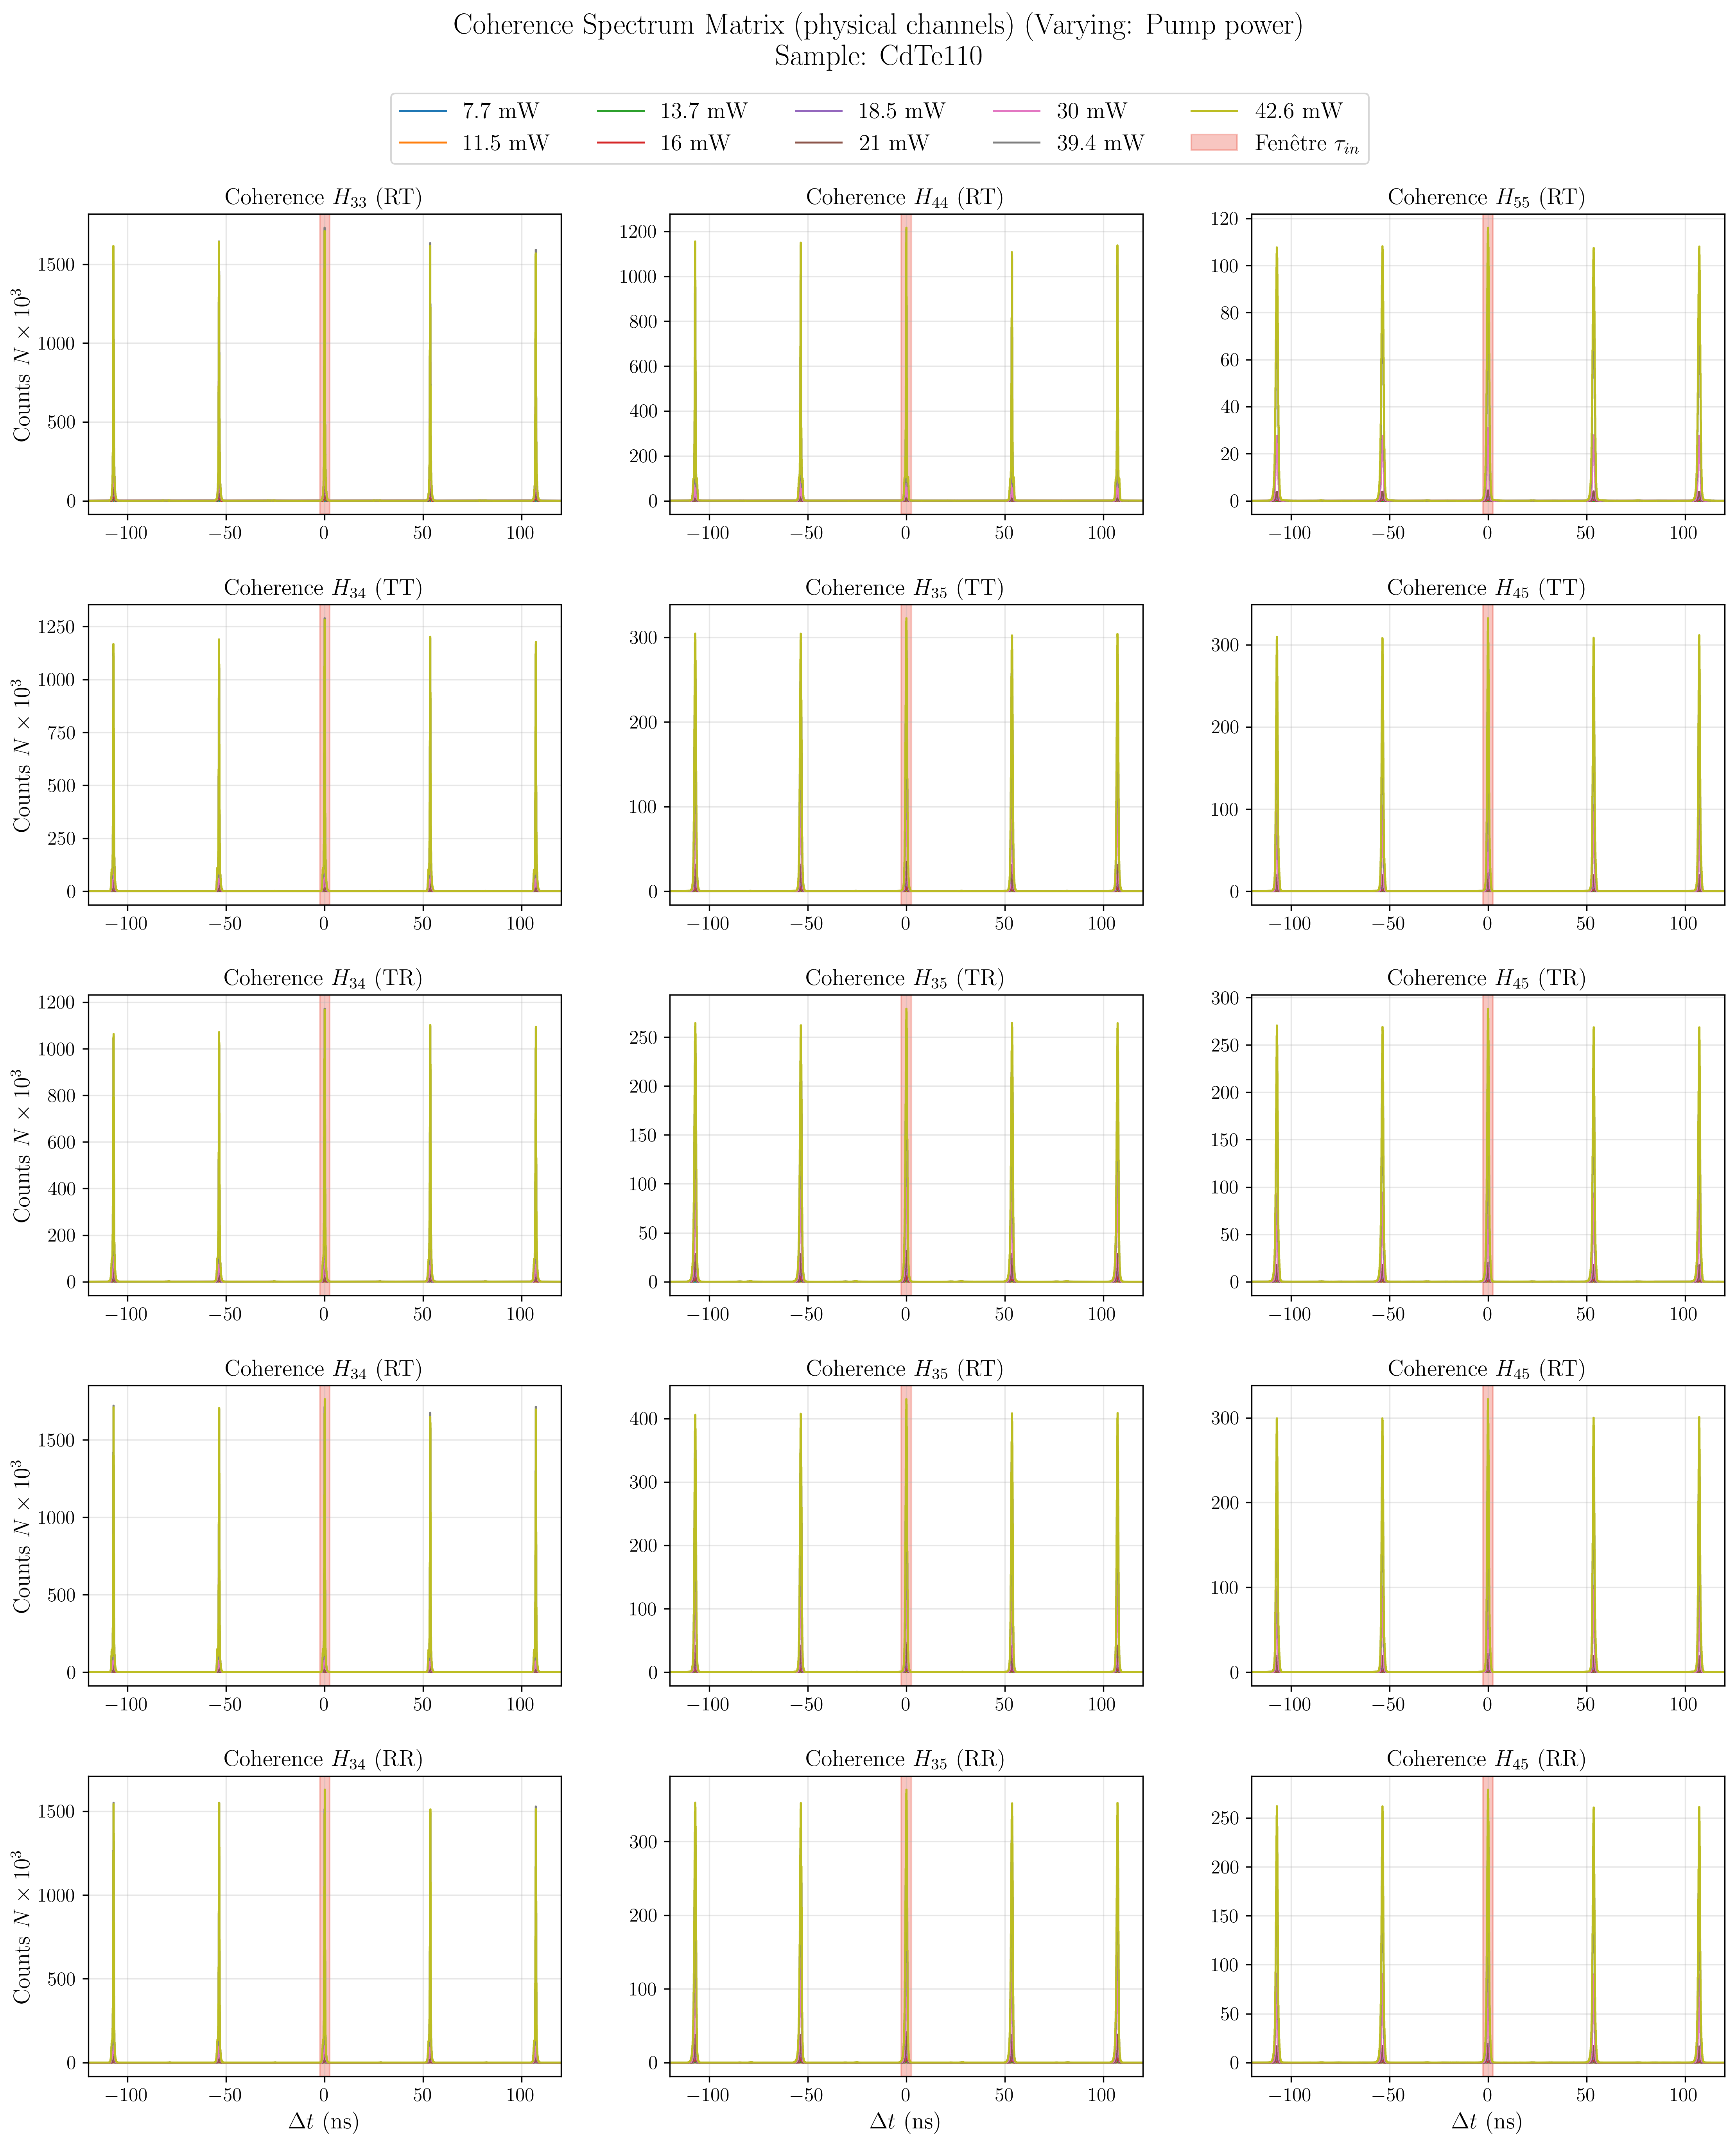

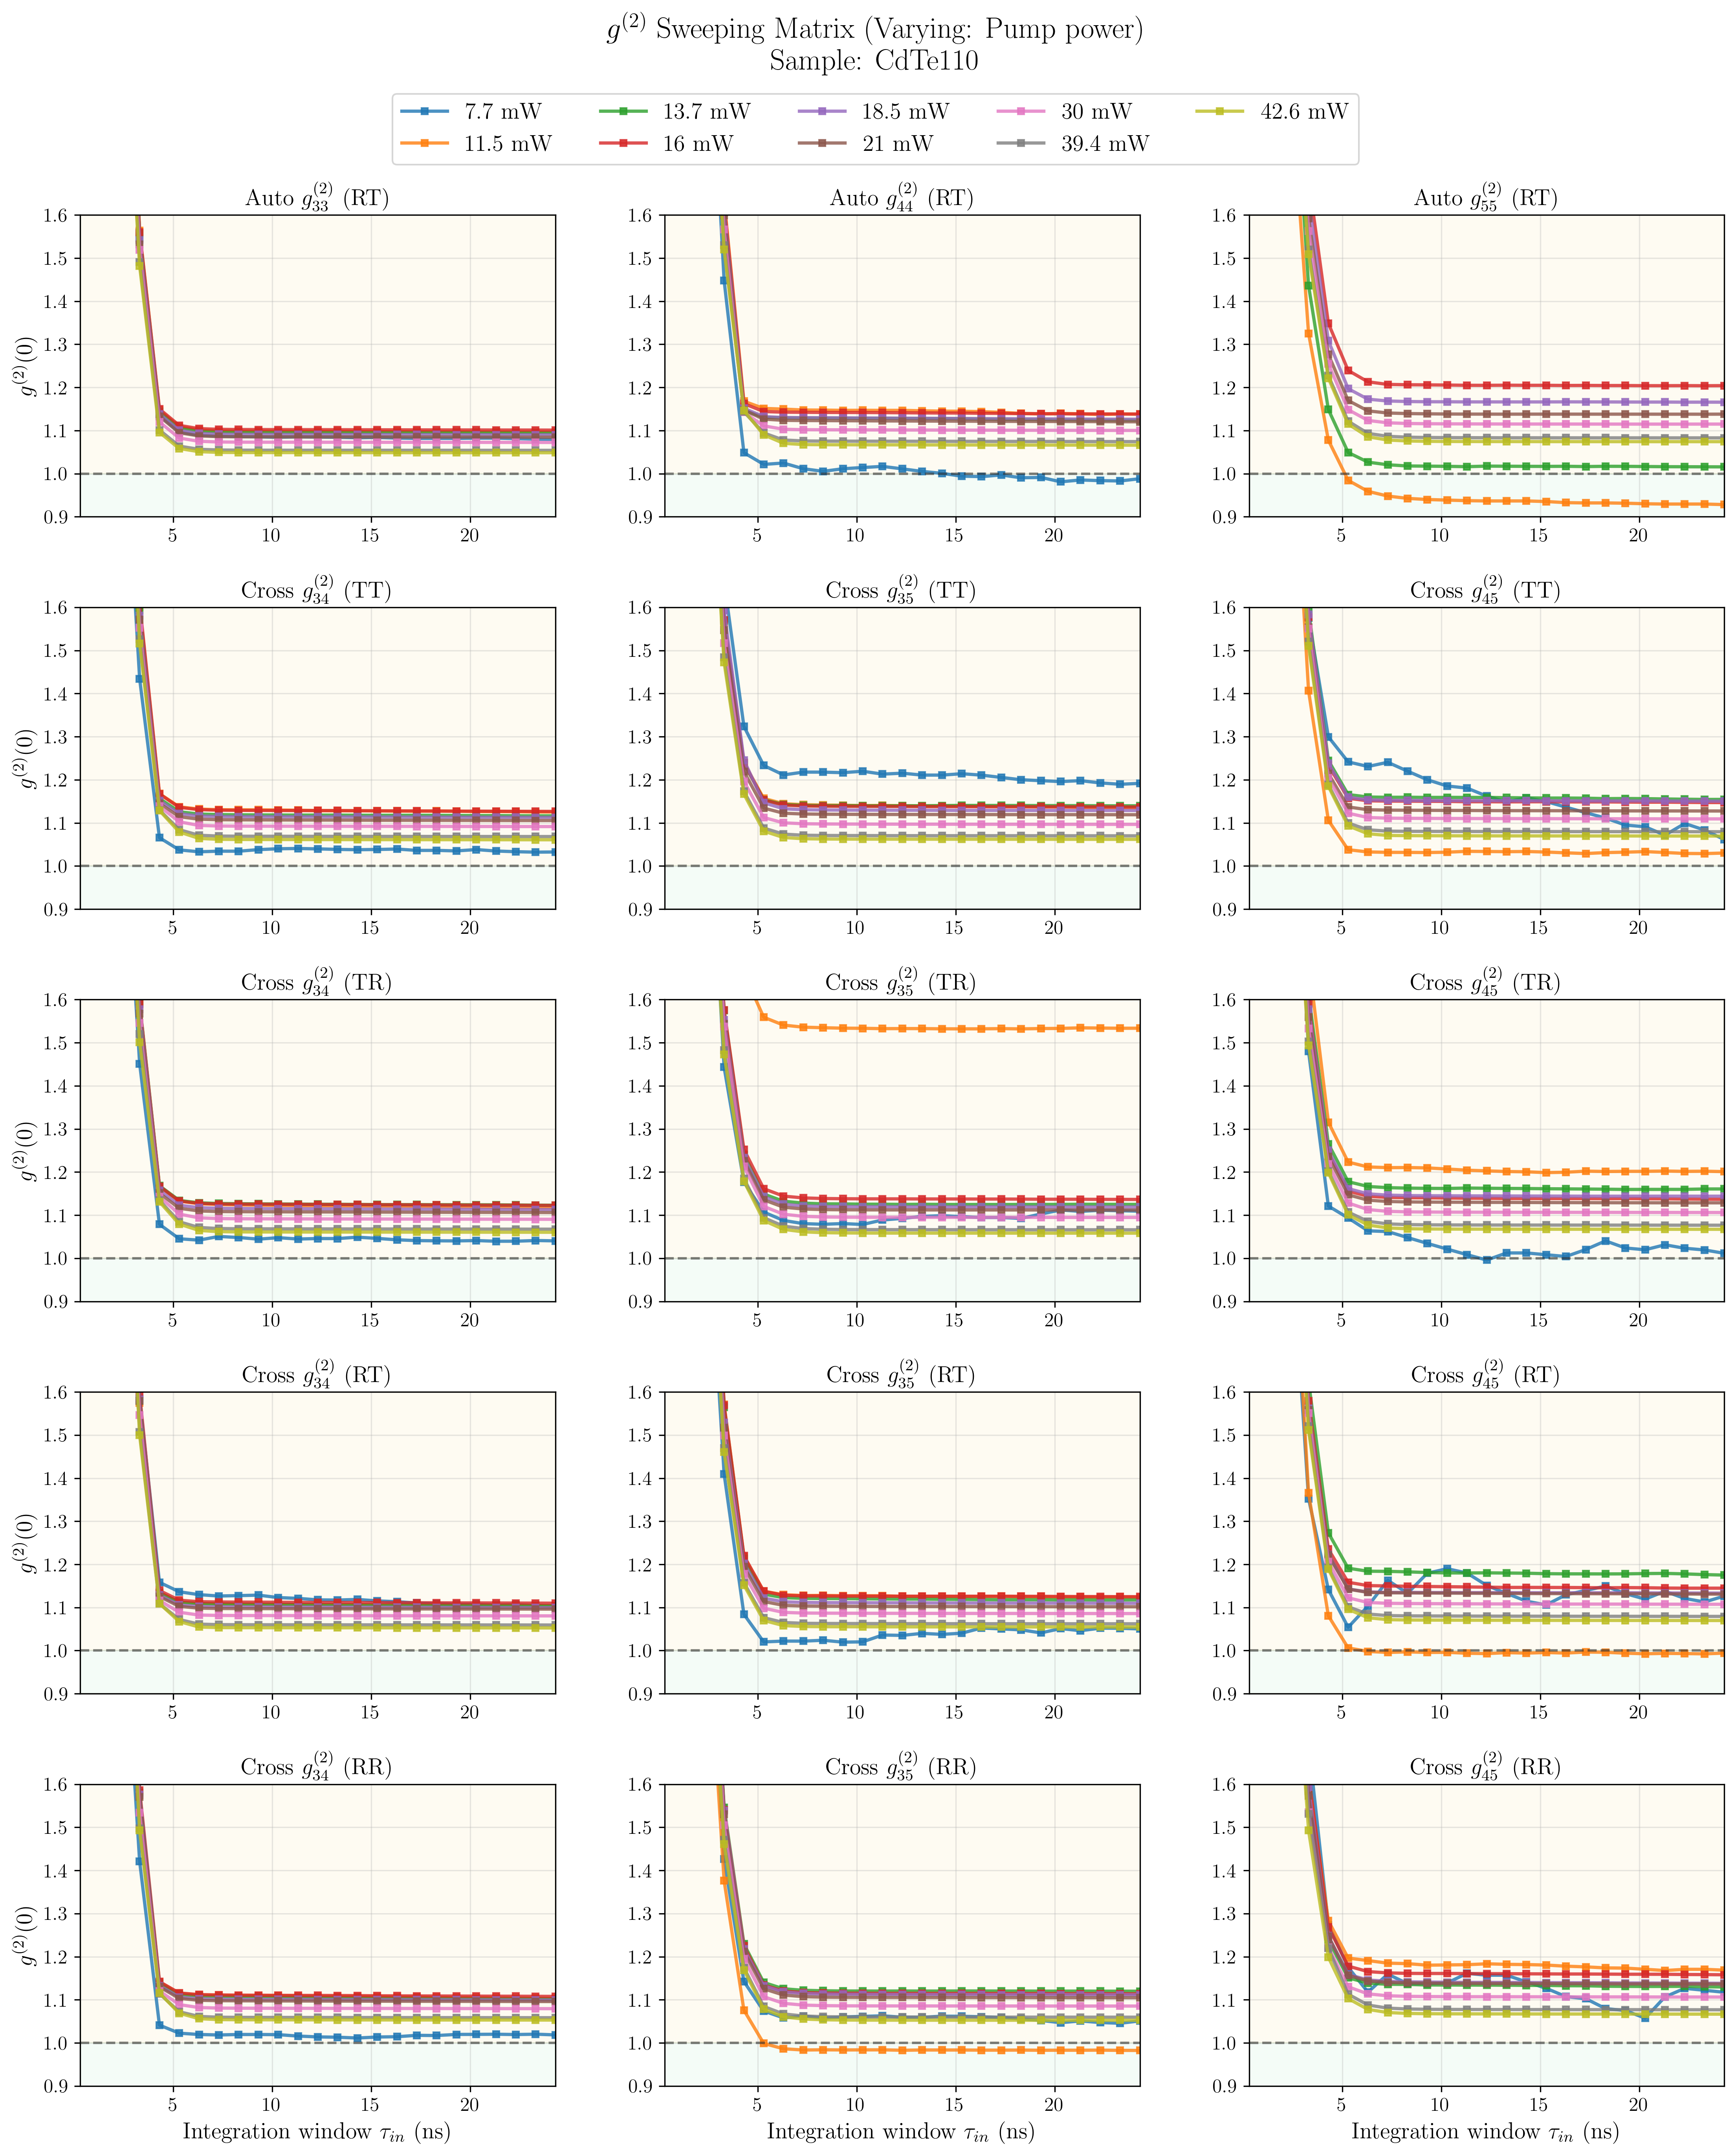

(<Figure size 5400x6000 with 15 Axes>,
 array([[<Axes: title={'center': 'Auto $g^{(2)}_{33}$ (RT)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Auto $g^{(2)}_{44}$ (RT)'}>,
         <Axes: title={'center': 'Auto $g^{(2)}_{55}$ (RT)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (TT)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Cross $g^{(2)}_{35}$ (TT)'}>,
         <Axes: title={'center': 'Cross $g^{(2)}_{45}$ (TT)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (TR)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Cross $g^{(2)}_{35}$ (TR)'}>,
         <Axes: title={'center': 'Cross $g^{(2)}_{45}$ (TR)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (RT)'}, ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': 'Cross $g^{(2)}_{35}$ (RT)'}>,
         <Axes: title={'center': 'Cross $g^{(2)}_{45}$ (RT)'}>],
        [<Axes: title={'center': 'Cross $g^{(2)}_{34}$ (RR)'}, xlabel='Integration window $\\tau_{in

In [3]:
comp = GridVisualizer(runs, comparison_variable="Pump power")
ref = runs[0]

comp.plot_coherence(xlim=120, integration_window_ns=5.0)
comp.plot_g2(methods=['delay'], tau_min=0.3, tau_max=25, step=1.0)

In [4]:
TAU_INT = 10.0

## 3. Build the analyzer & numeric table

`PowerScanAnalyzer` assembles, for every power: the harmonic intensities $\langle I_n\rangle$,
the local exponents $K(n)$, the auto/cross $g^{(2)}(0)$, and the rescaled collapse
$(g^{(2)}_n-1)/K^2(n)$.

In [5]:
psa = PowerScanAnalyzer(runs, harmonics=(3, 4, 5), tau_in_ns=TAU_INT, g2_method='delay')
psa.summary_table()

   P(mW)         I3         I4         I5     K3     K4     K5   g2_33   g2_44   g2_55  (g-1)/K2_3  (g-1)/K2_4  (g-1)/K2_5
--------------------------------------------------------------------------------------------------------------------------
     7.7  3.924e+04       9428      771.1   2.88   3.32   4.87   1.085   1.017   2.087      0.0102      0.0015      0.0458
    11.5  1.248e+05  3.577e+04       5447   2.88   3.60   4.84   1.099   1.147   0.939      0.0119      0.0114     -0.0026
    13.7  2.063e+05  6.855e+04  1.267e+04   2.89   3.80   4.85   1.096   1.128   1.017      0.0115      0.0089      0.0007
    16.0  3.241e+05  1.249e+05  2.702e+04   2.94   3.90   4.86   1.102   1.142   1.206      0.0118      0.0093      0.0087
    18.5  4.984e+05  2.211e+05   5.46e+04   3.01   4.02   4.94   1.091   1.129   1.167      0.0100      0.0080      0.0068
    21.0  7.345e+05  3.717e+05  1.033e+05   2.95   3.96   4.85   1.085   1.123   1.138      0.0098      0.0078      0.0059
    30.0  1.888e

## 4. Intensity scaling — verification (3)

$\log\langle I_n\rangle$ vs $\log I_0$. The straight low-power part has slope $K(n)\approx n$
(dashed = ideal slope $n$); the bend at high power is saturation. The companion plot shows the
**local exponent** $K(n)$ that quantifies the bend (dotted = ideal order $n$).

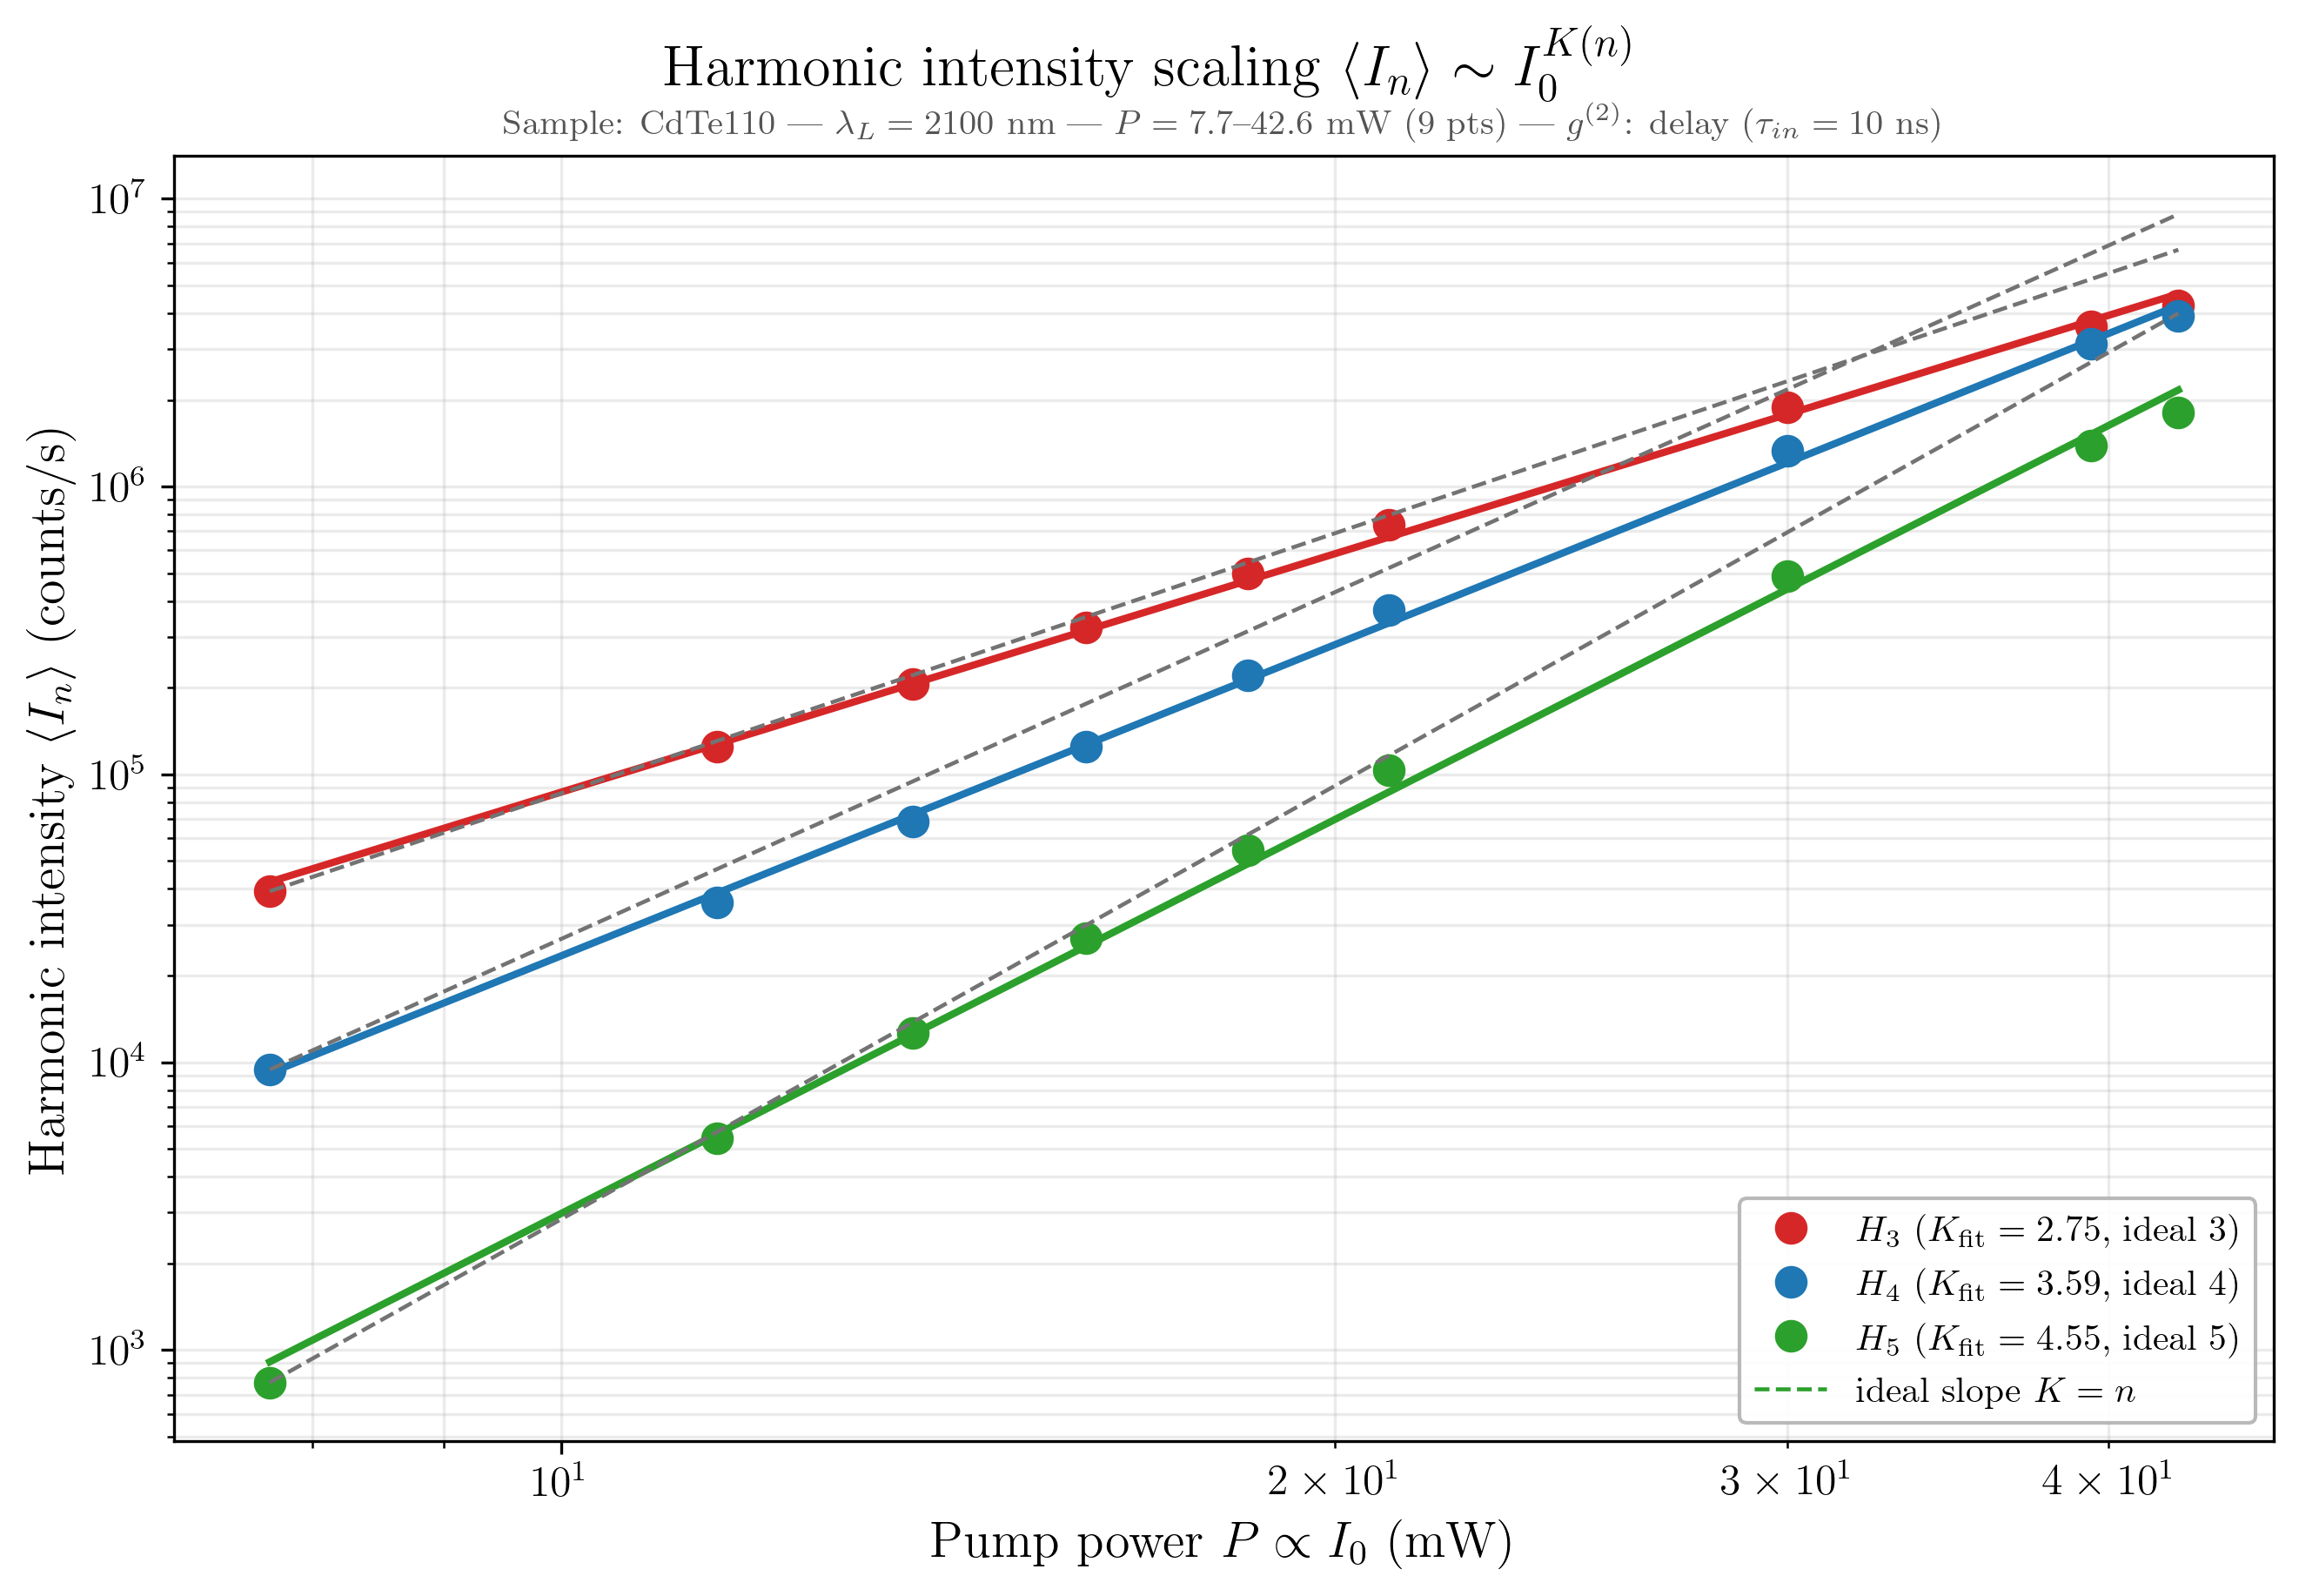

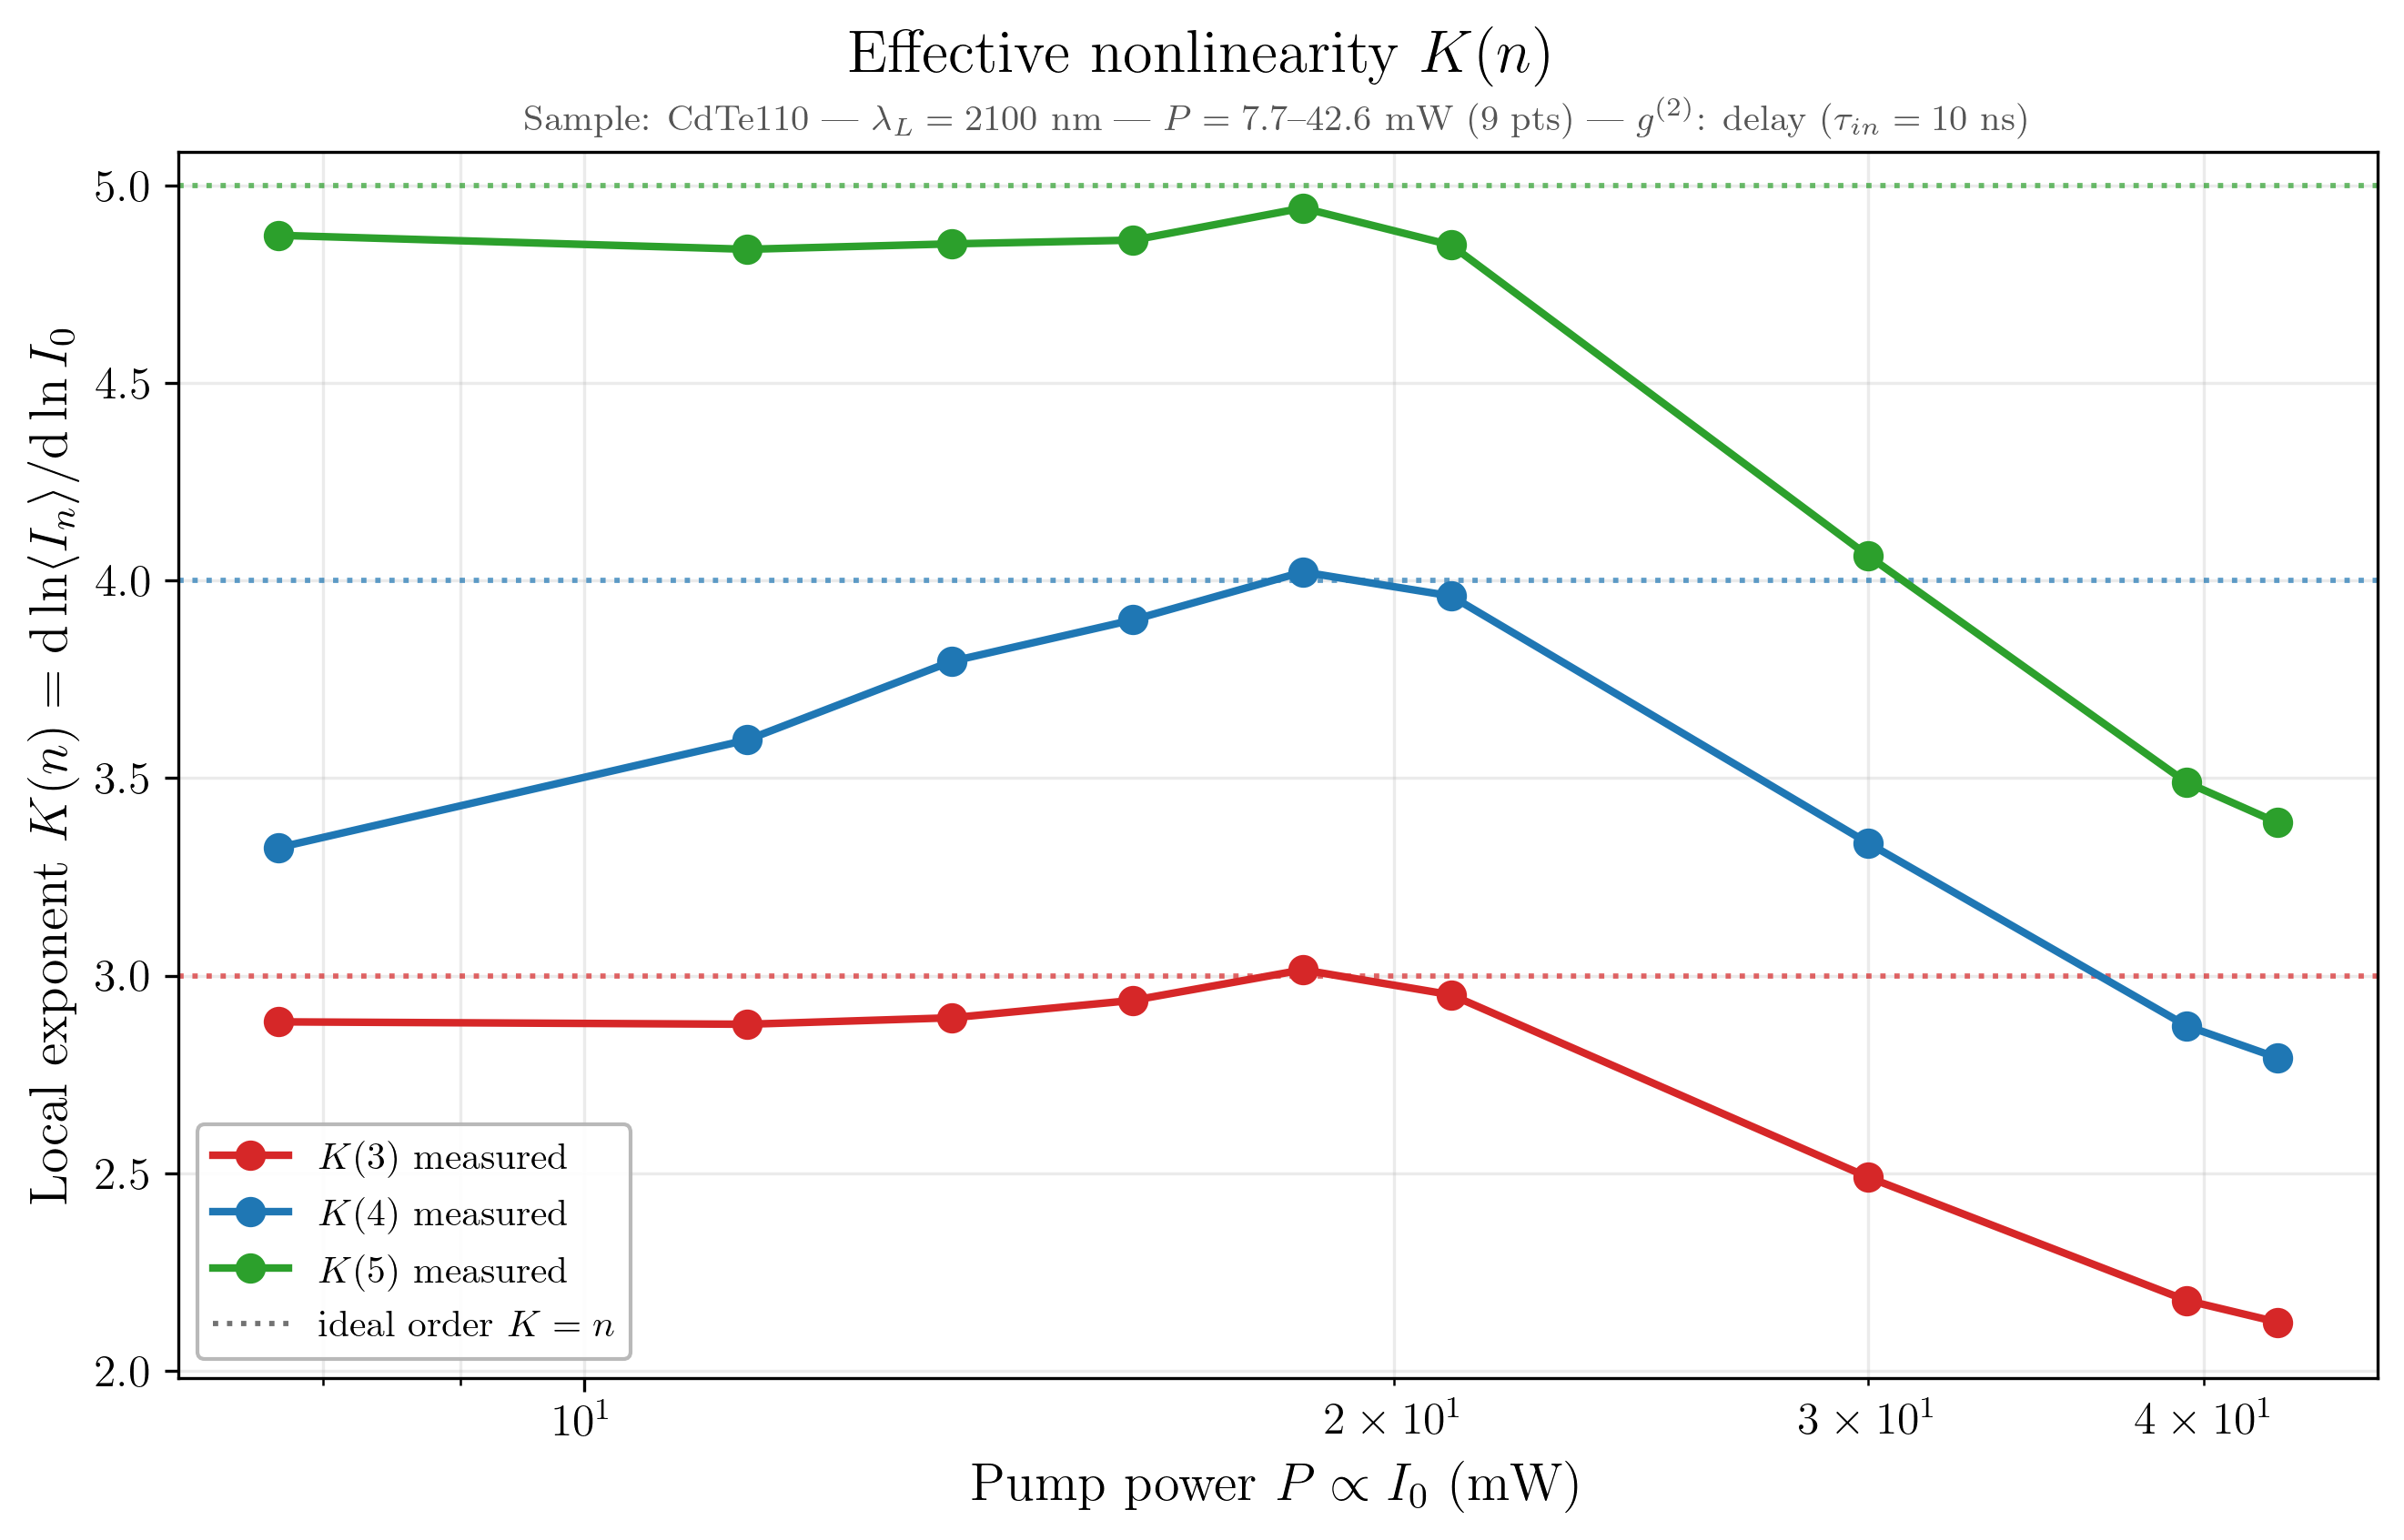

(<Figure size 2700x1800 with 1 Axes>,
 <Axes: title={'center': 'Sample: CdTe110  |  $\\lambda_L = 2100$ nm  |  $P = 7.7$--$42.6$ mW (9 pts)  |  $g^{(2)}$: delay ($\\tau_{in} = 10$ ns)'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='Local exponent $K(n) = \\mathrm{d}\\ln\\langle I_n\\rangle/\\mathrm{d}\\ln I_0$'>)

In [6]:
psa.plot_intensity_scaling(n_fit=9)
psa.plot_local_slope()

## 5. $g^{(2)}(0)$ vs pump power — verification (1)

A family of distinct curves. Auto-correlations $g^{(2)}_{nn}$ (solid) and the cross pairs
$g^{(2)}_{mn}$ (dashed). Higher harmonics (larger $K$) are more bunched.

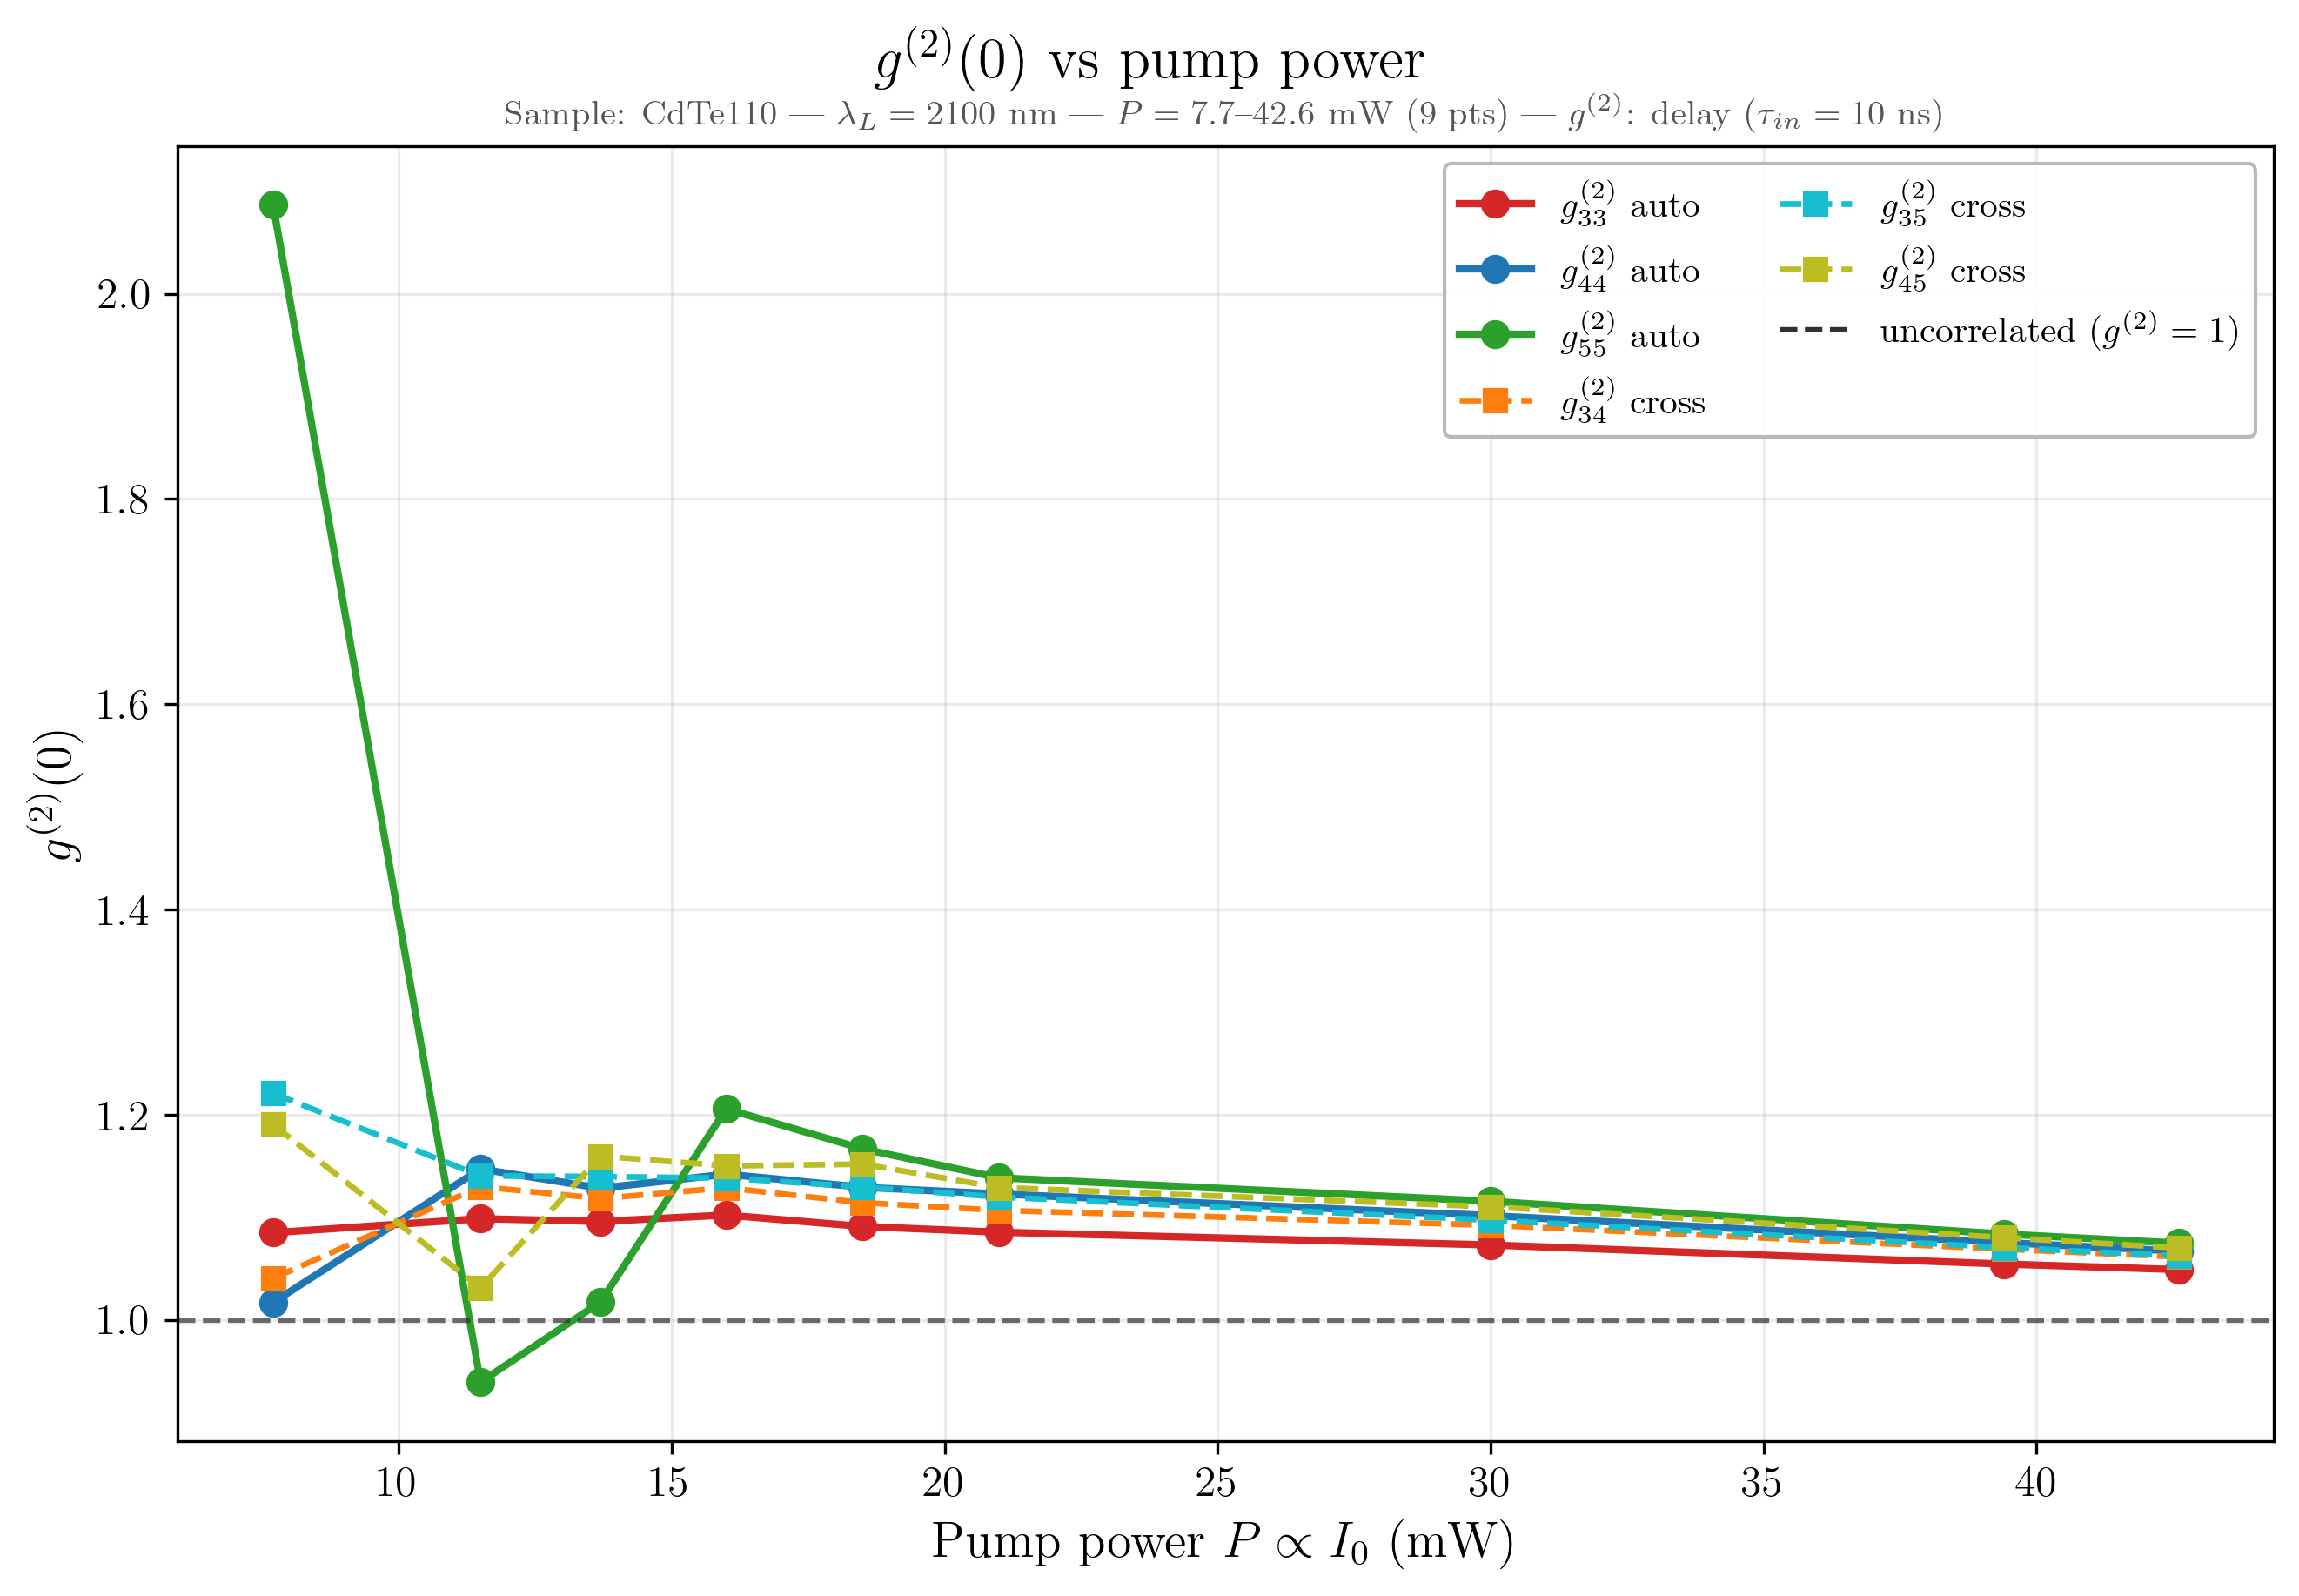

(<Figure size 2700x1950 with 1 Axes>,
 <Axes: title={'center': 'Sample: CdTe110  |  $\\lambda_L = 2100$ nm  |  $P = 7.7$--$42.6$ mW (9 pts)  |  $g^{(2)}$: delay ($\\tau_{in} = 10$ ns)'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='$g^{(2)}(0)$'>)

In [7]:
psa.plot_g2_vs_power(include_cross=True)

## 6. The collapse — verification (2), the key test

Dividing by $K^2(n)$ (auto) or $K(m)K(n)$ (cross) should make **every** curve fall on the same
universal line $g^{(2)}_0-1=\sigma^2$. The black curve is the mean over all harmonics/pairs: our
**indirect measurement of the pump bunching** $\sigma^2$ (shaded = spread between harmonics).

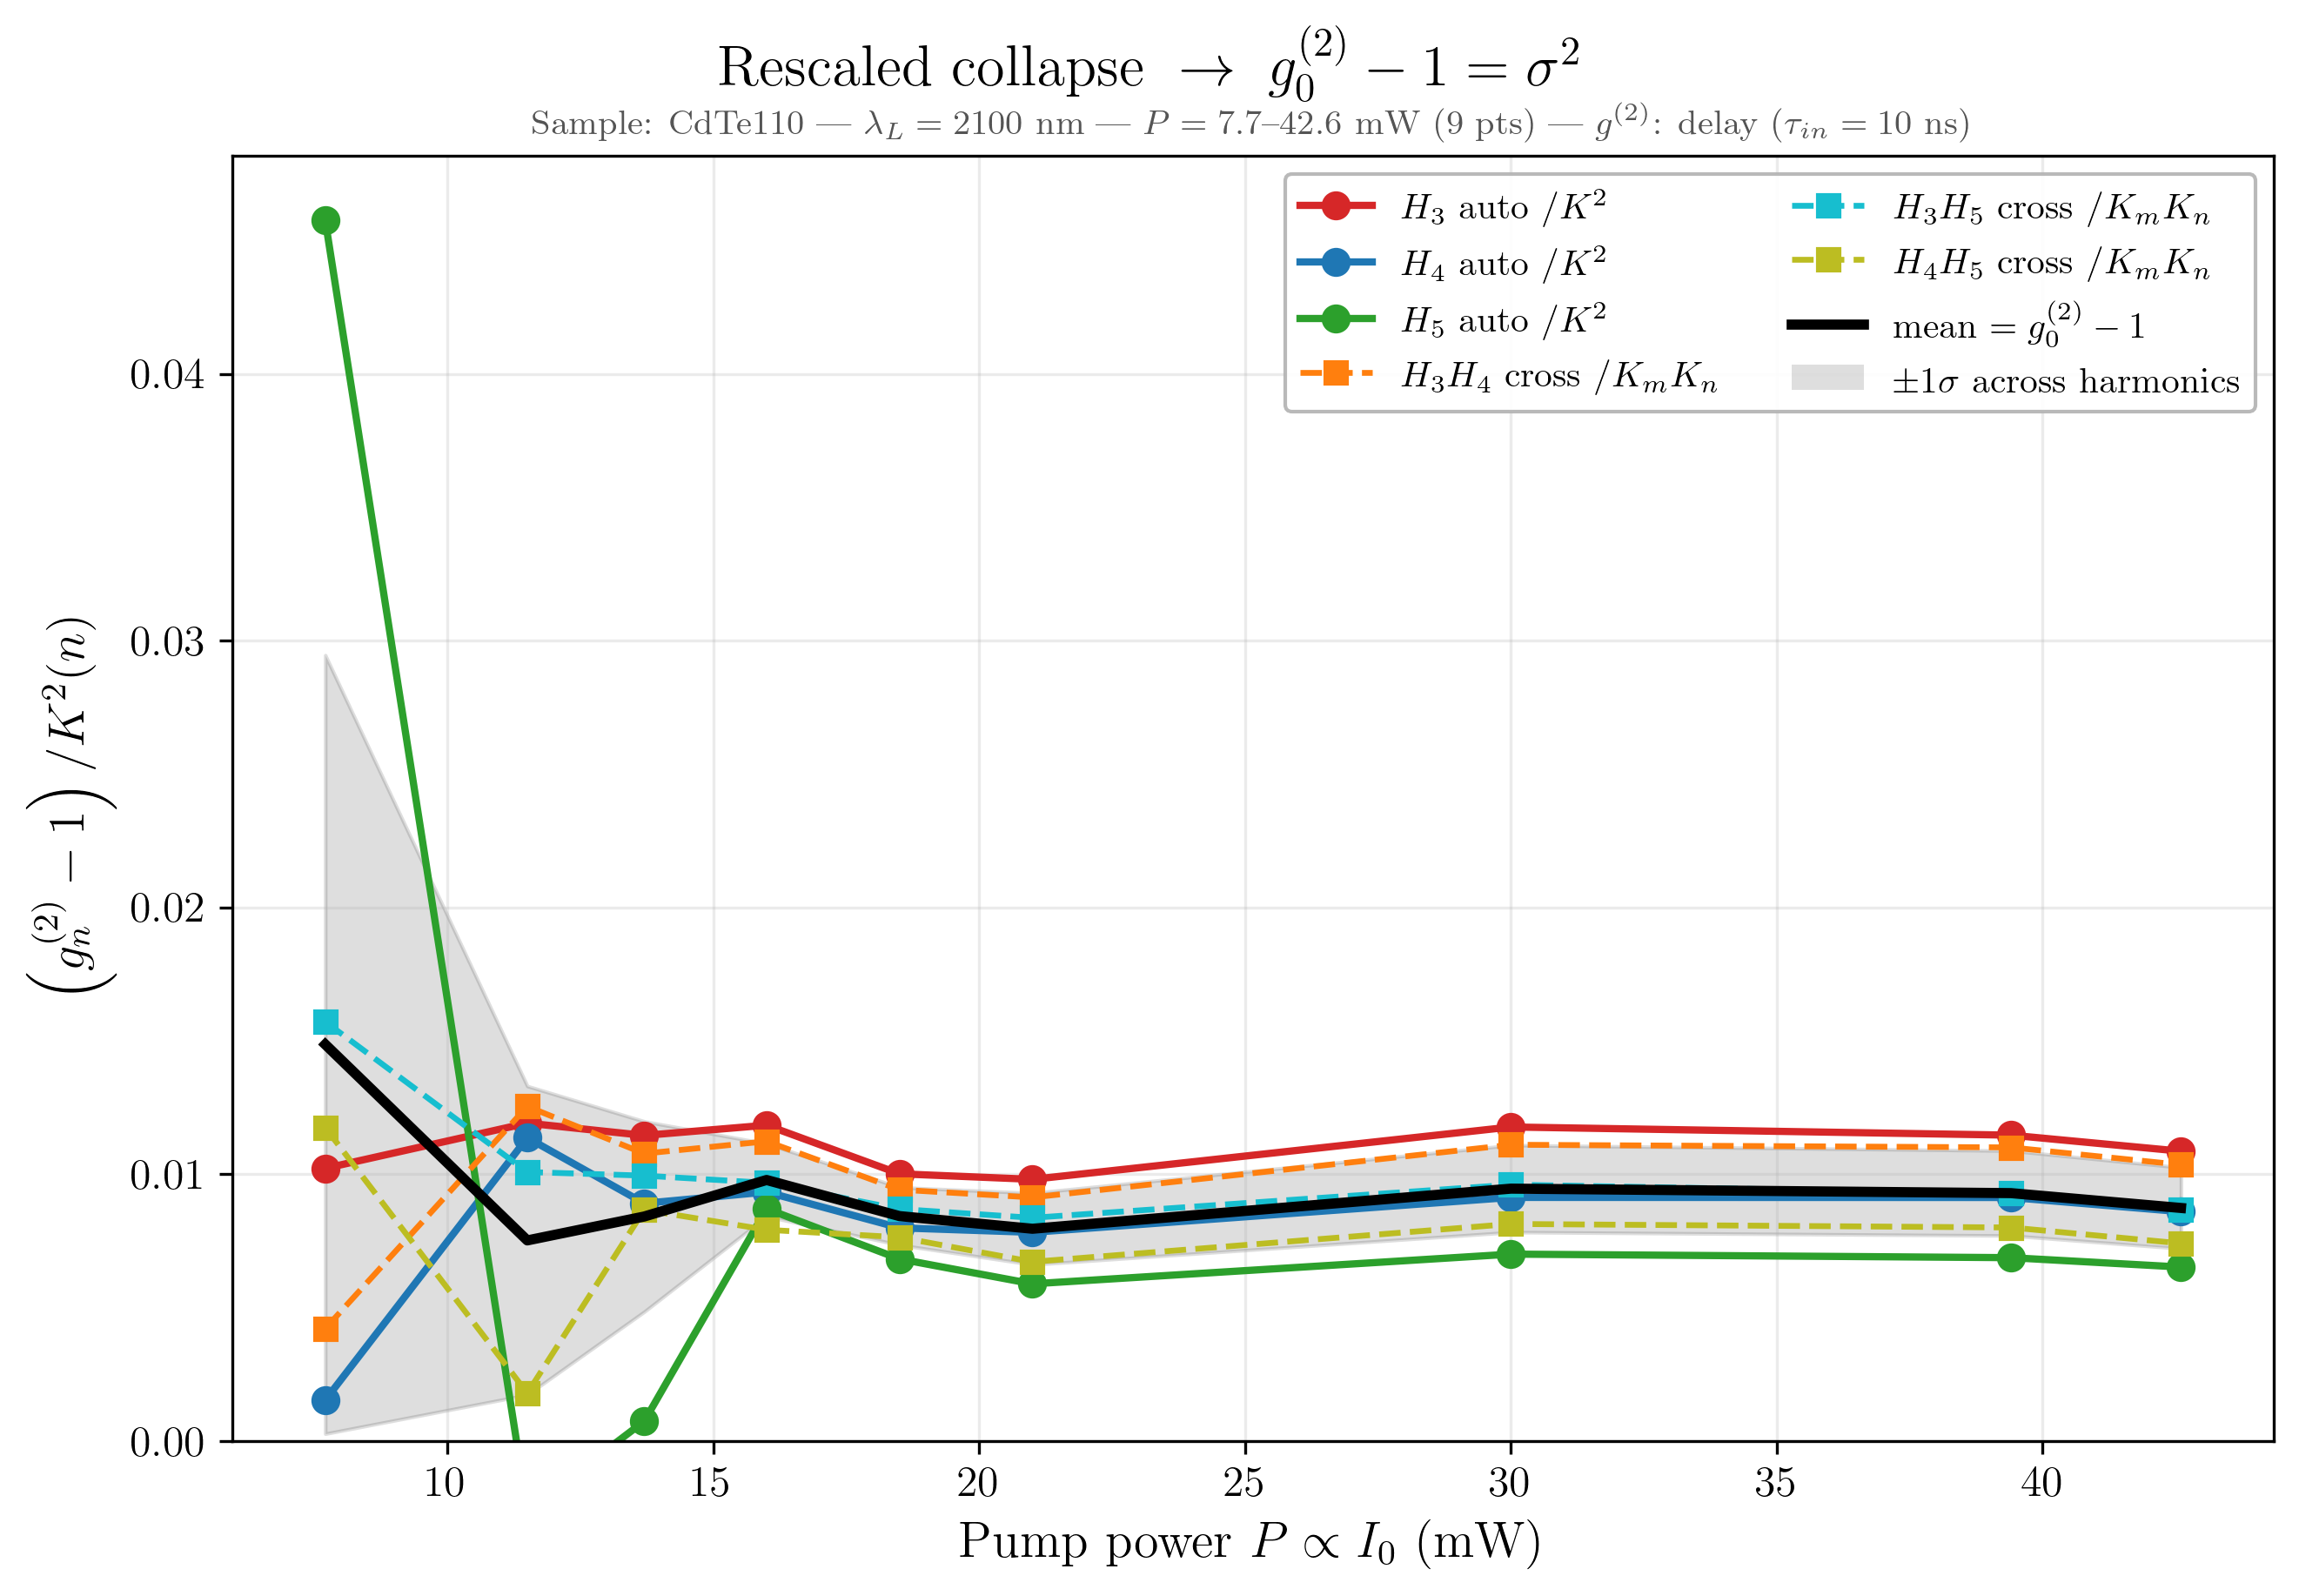

Inferred pump excess  g2_0 - 1 = sigma^2  (mean over harmonics, per power):
  P =    7.7 mW :  sigma^2 = 0.0149  +/- 0.0146
  P =   11.5 mW :  sigma^2 = 0.0075  +/- 0.0058
  P =   13.7 mW :  sigma^2 = 0.0084  +/- 0.0036
  P =   16.0 mW :  sigma^2 = 0.0098  +/- 0.0014
  P =   18.5 mW :  sigma^2 = 0.0084  +/- 0.0011
  P =   21.0 mW :  sigma^2 = 0.0080  +/- 0.0013
  P =   30.0 mW :  sigma^2 = 0.0095  +/- 0.0016
  P =   39.4 mW :  sigma^2 = 0.0093  +/- 0.0016
  P =   42.6 mW :  sigma^2 = 0.0087  +/- 0.0015

Scan-averaged sigma^2 = 0.0094  ->  g2_0 ~ 1.0094


In [8]:
psa.plot_g2_collapse(slope='local', include_cross=True)

mean, std = psa.inferred_g2_0()
print("Inferred pump excess  g2_0 - 1 = sigma^2  (mean over harmonics, per power):")
for P, m, s in zip(psa.I0, mean, std):
    print(f"  P = {P:6.1f} mW :  sigma^2 = {m:.4f}  +/- {s:.4f}")
print(f"\nScan-averaged sigma^2 = {np.nanmean(mean):.4f}  ->  g2_0 ~ {1+np.nanmean(mean):.4f}")

## 7. Full dashboard

The four panels together: $g^{(2)}$ vs power, the rescaled collapse, the intensity scaling and
the local exponent $K(n)$ — the complete picture of the model on one figure.

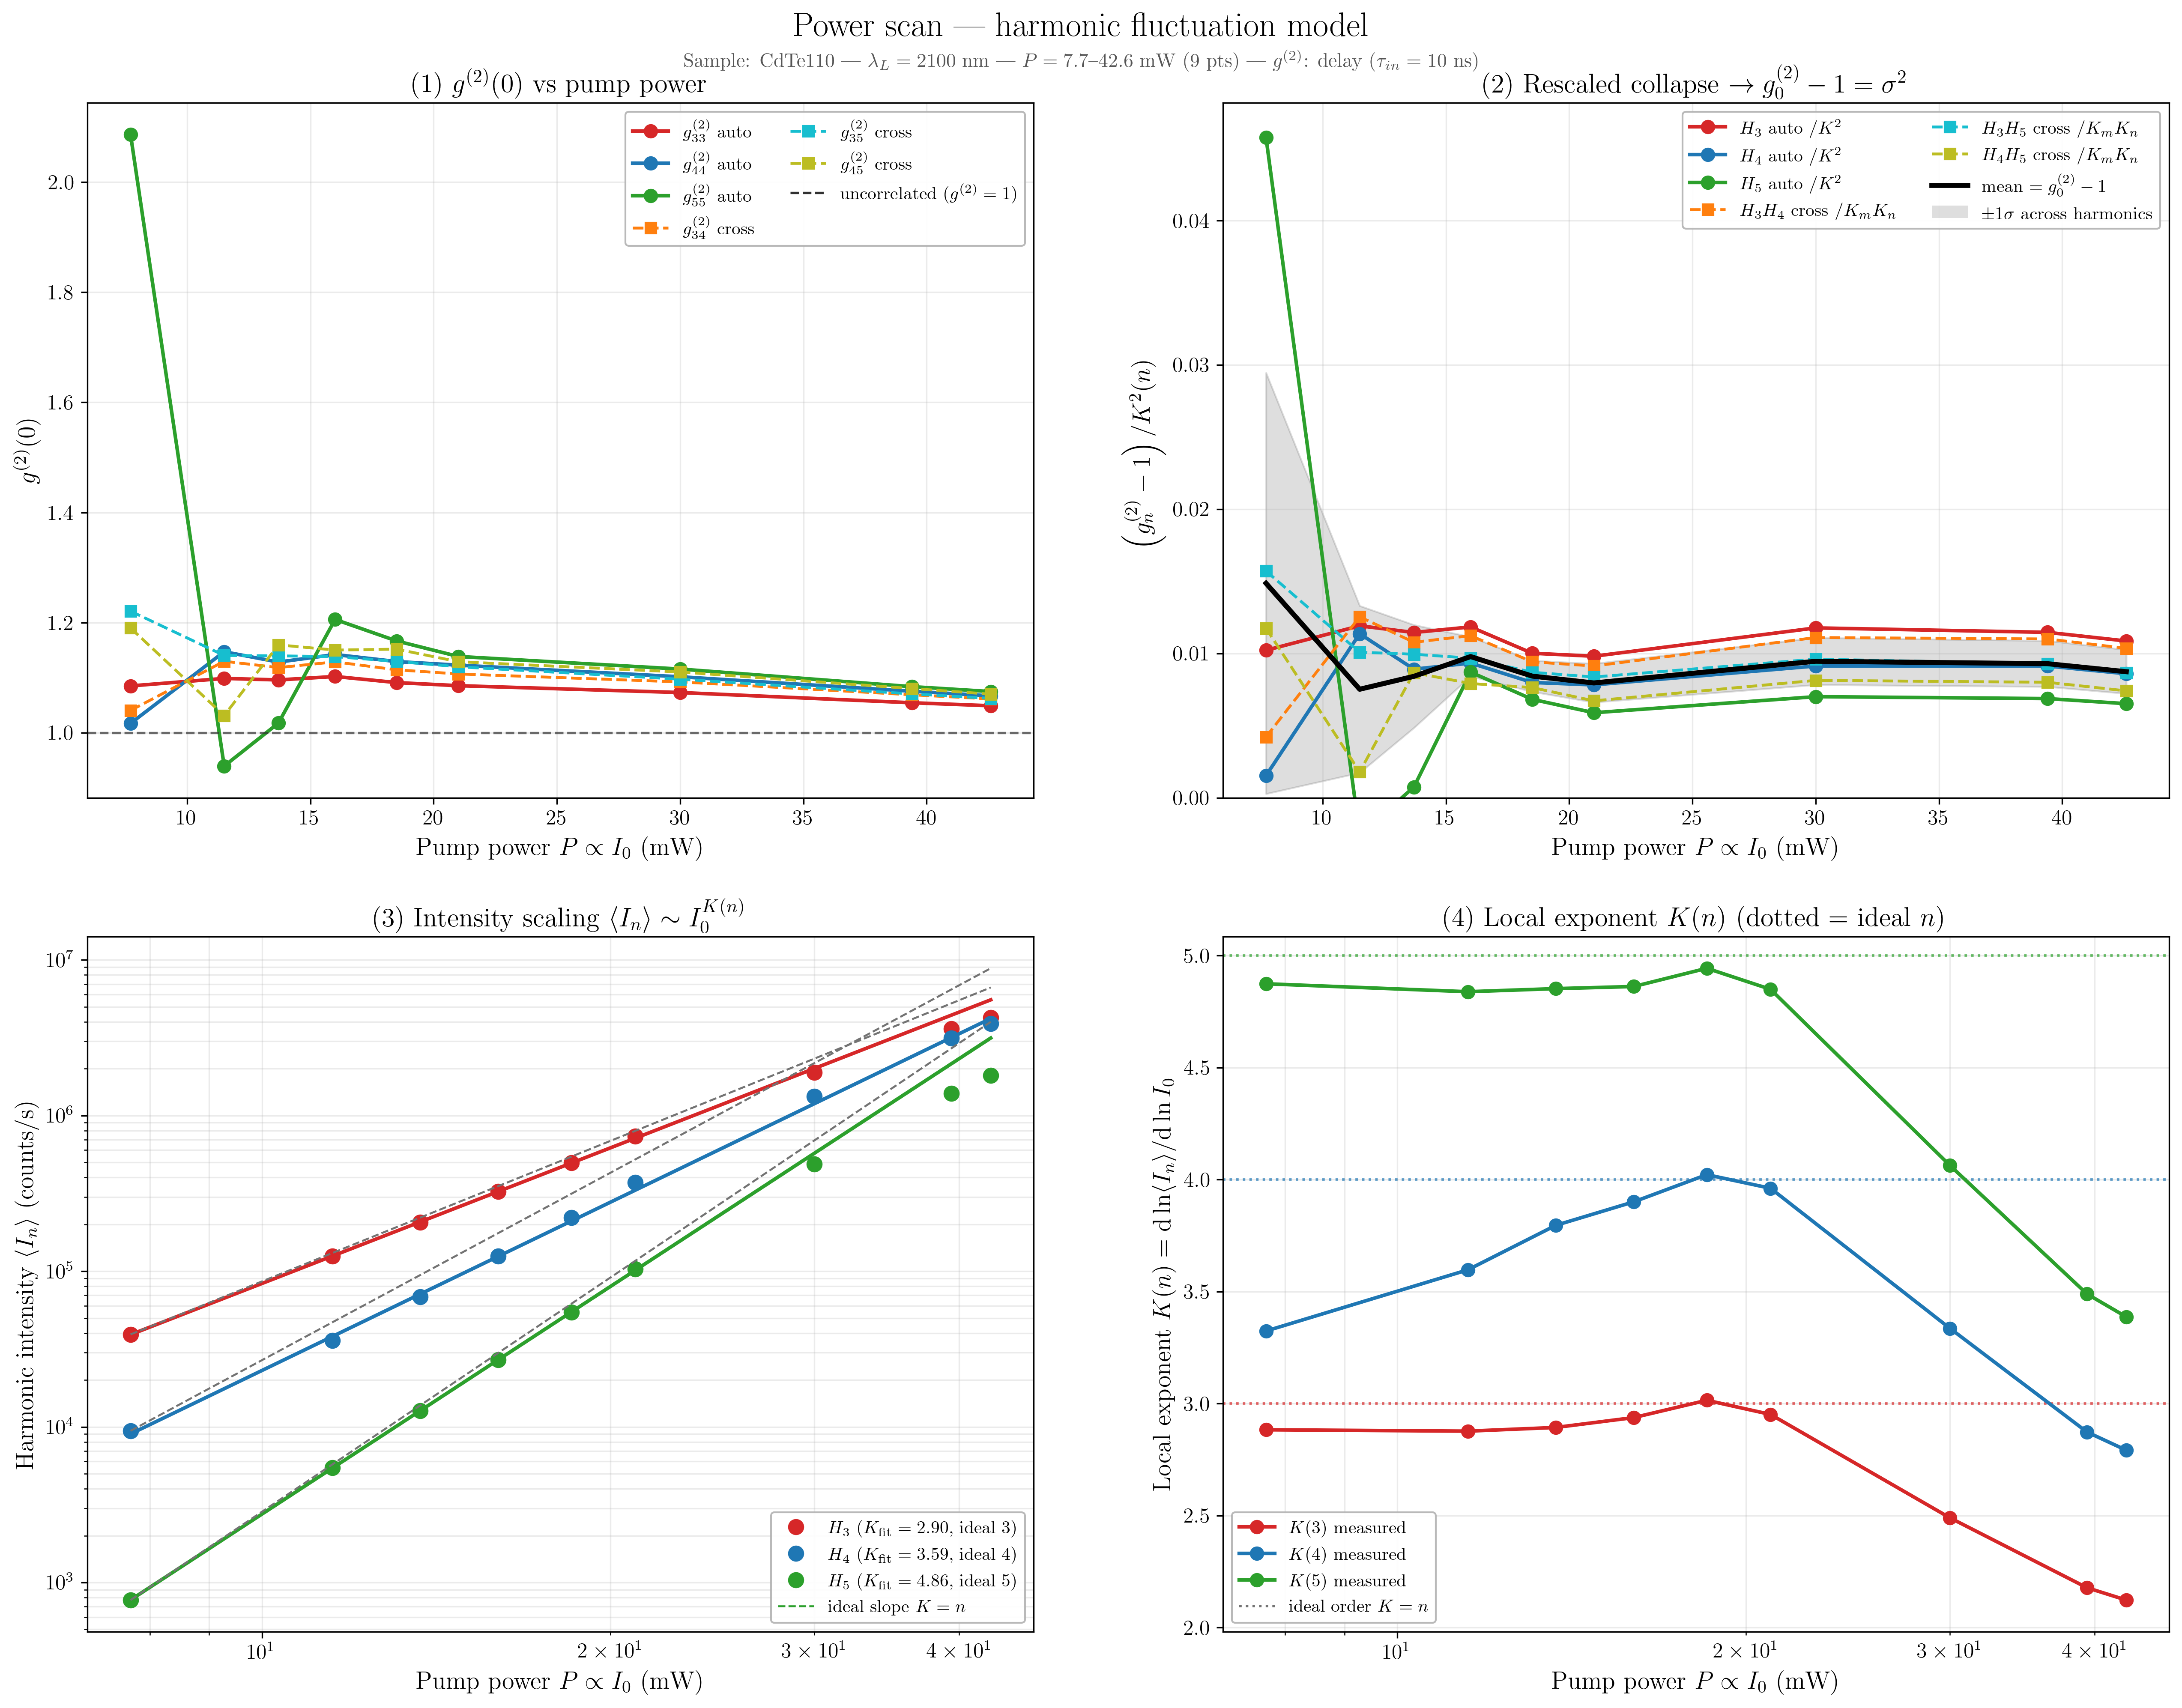

(<Figure size 5400x4200 with 4 Axes>,
 array([[<Axes: title={'center': '(1) $g^{(2)}(0)$ vs pump power'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='$g^{(2)}(0)$'>,
         <Axes: title={'center': '(2) Rescaled collapse $\\to g^{(2)}_0 - 1 = \\sigma^2$'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='$\\left(g^{(2)}_n - 1\\right)/K^2(n)$'>],
        [<Axes: title={'center': '(3) Intensity scaling $\\langle I_n\\rangle \\sim I_0^{K(n)}$'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='Harmonic intensity $\\langle I_n\\rangle$ (counts/s)'>,
         <Axes: title={'center': '(4) Local exponent $K(n)$  (dotted = ideal $n$)'}, xlabel='Pump power $P \\propto I_0$ (mW)', ylabel='Local exponent $K(n) = \\mathrm{d}\\ln\\langle I_n\\rangle/\\mathrm{d}\\ln I_0$'>]],
       dtype=object))

In [9]:
psa.plot_overview(slope='local', n_fit=5)

## 8. (optional) Per-pair matrices vs power

`GridVisualizer` plots the full $5\times3$ $g^{(2)}$ matrix and $4\times3$ Cauchy–Schwarz $R$
matrix, every panel as a function of power at the chosen window — handy to scan every channel
pair at once.

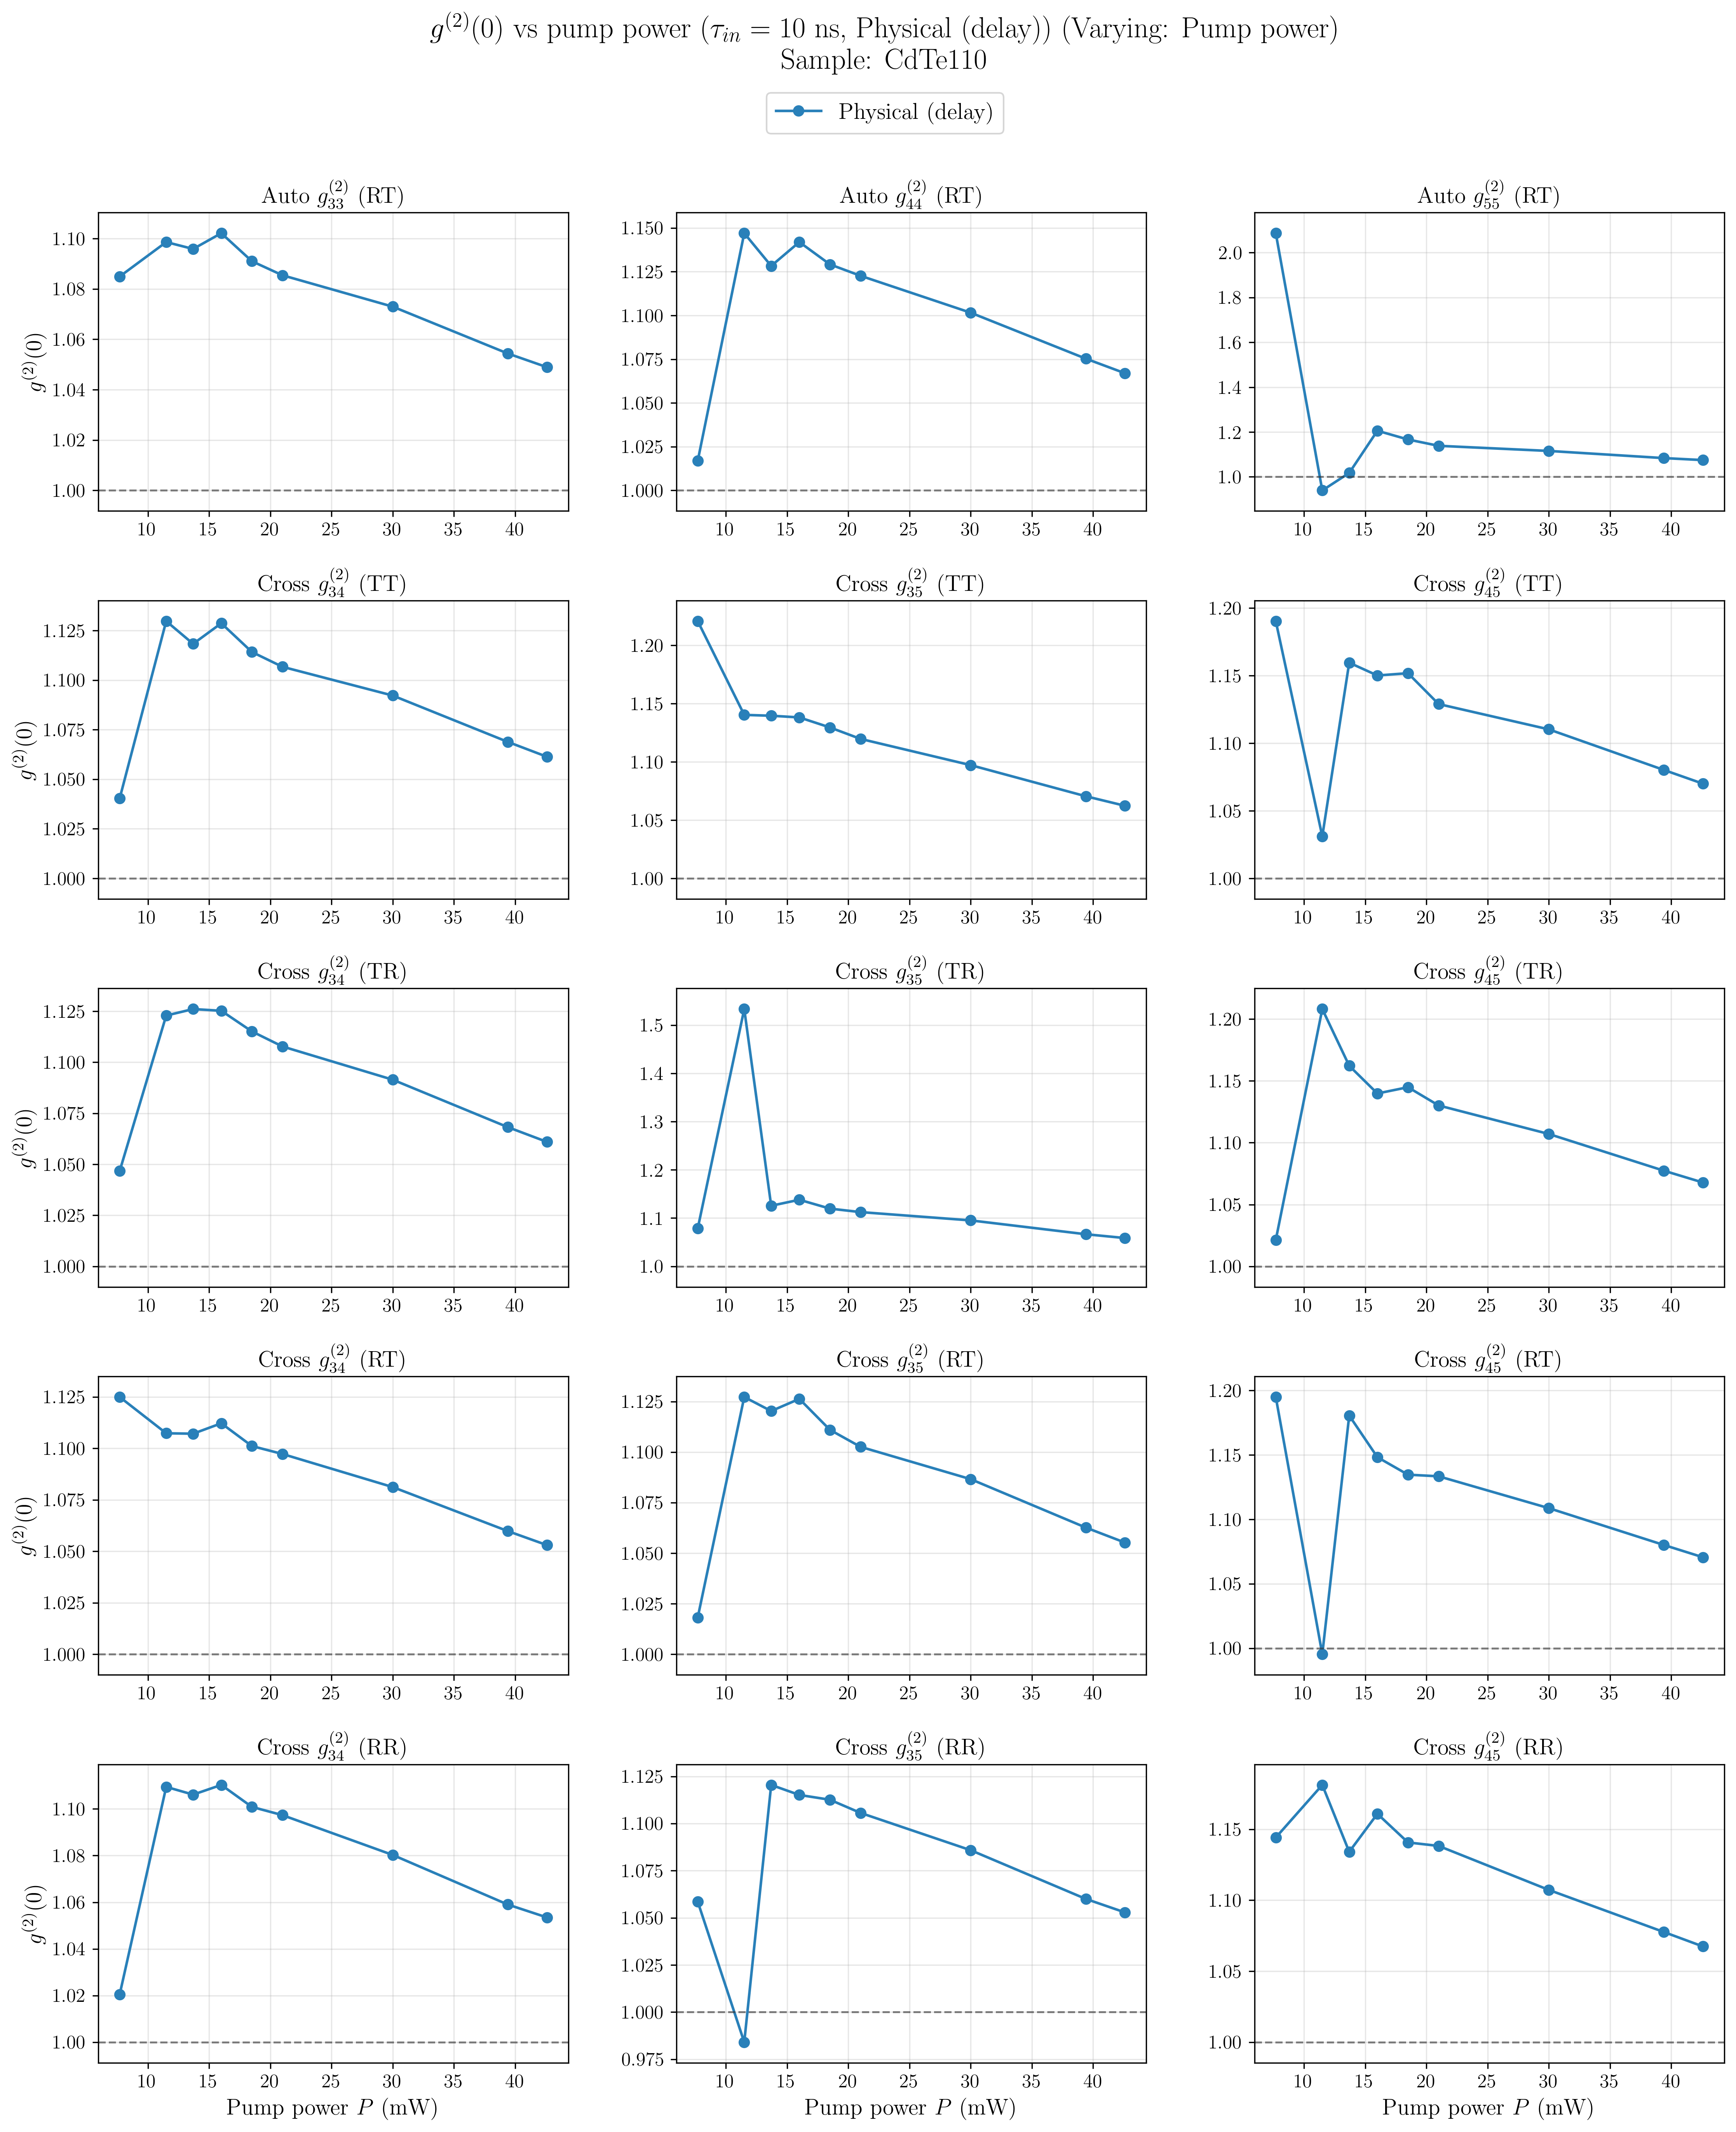

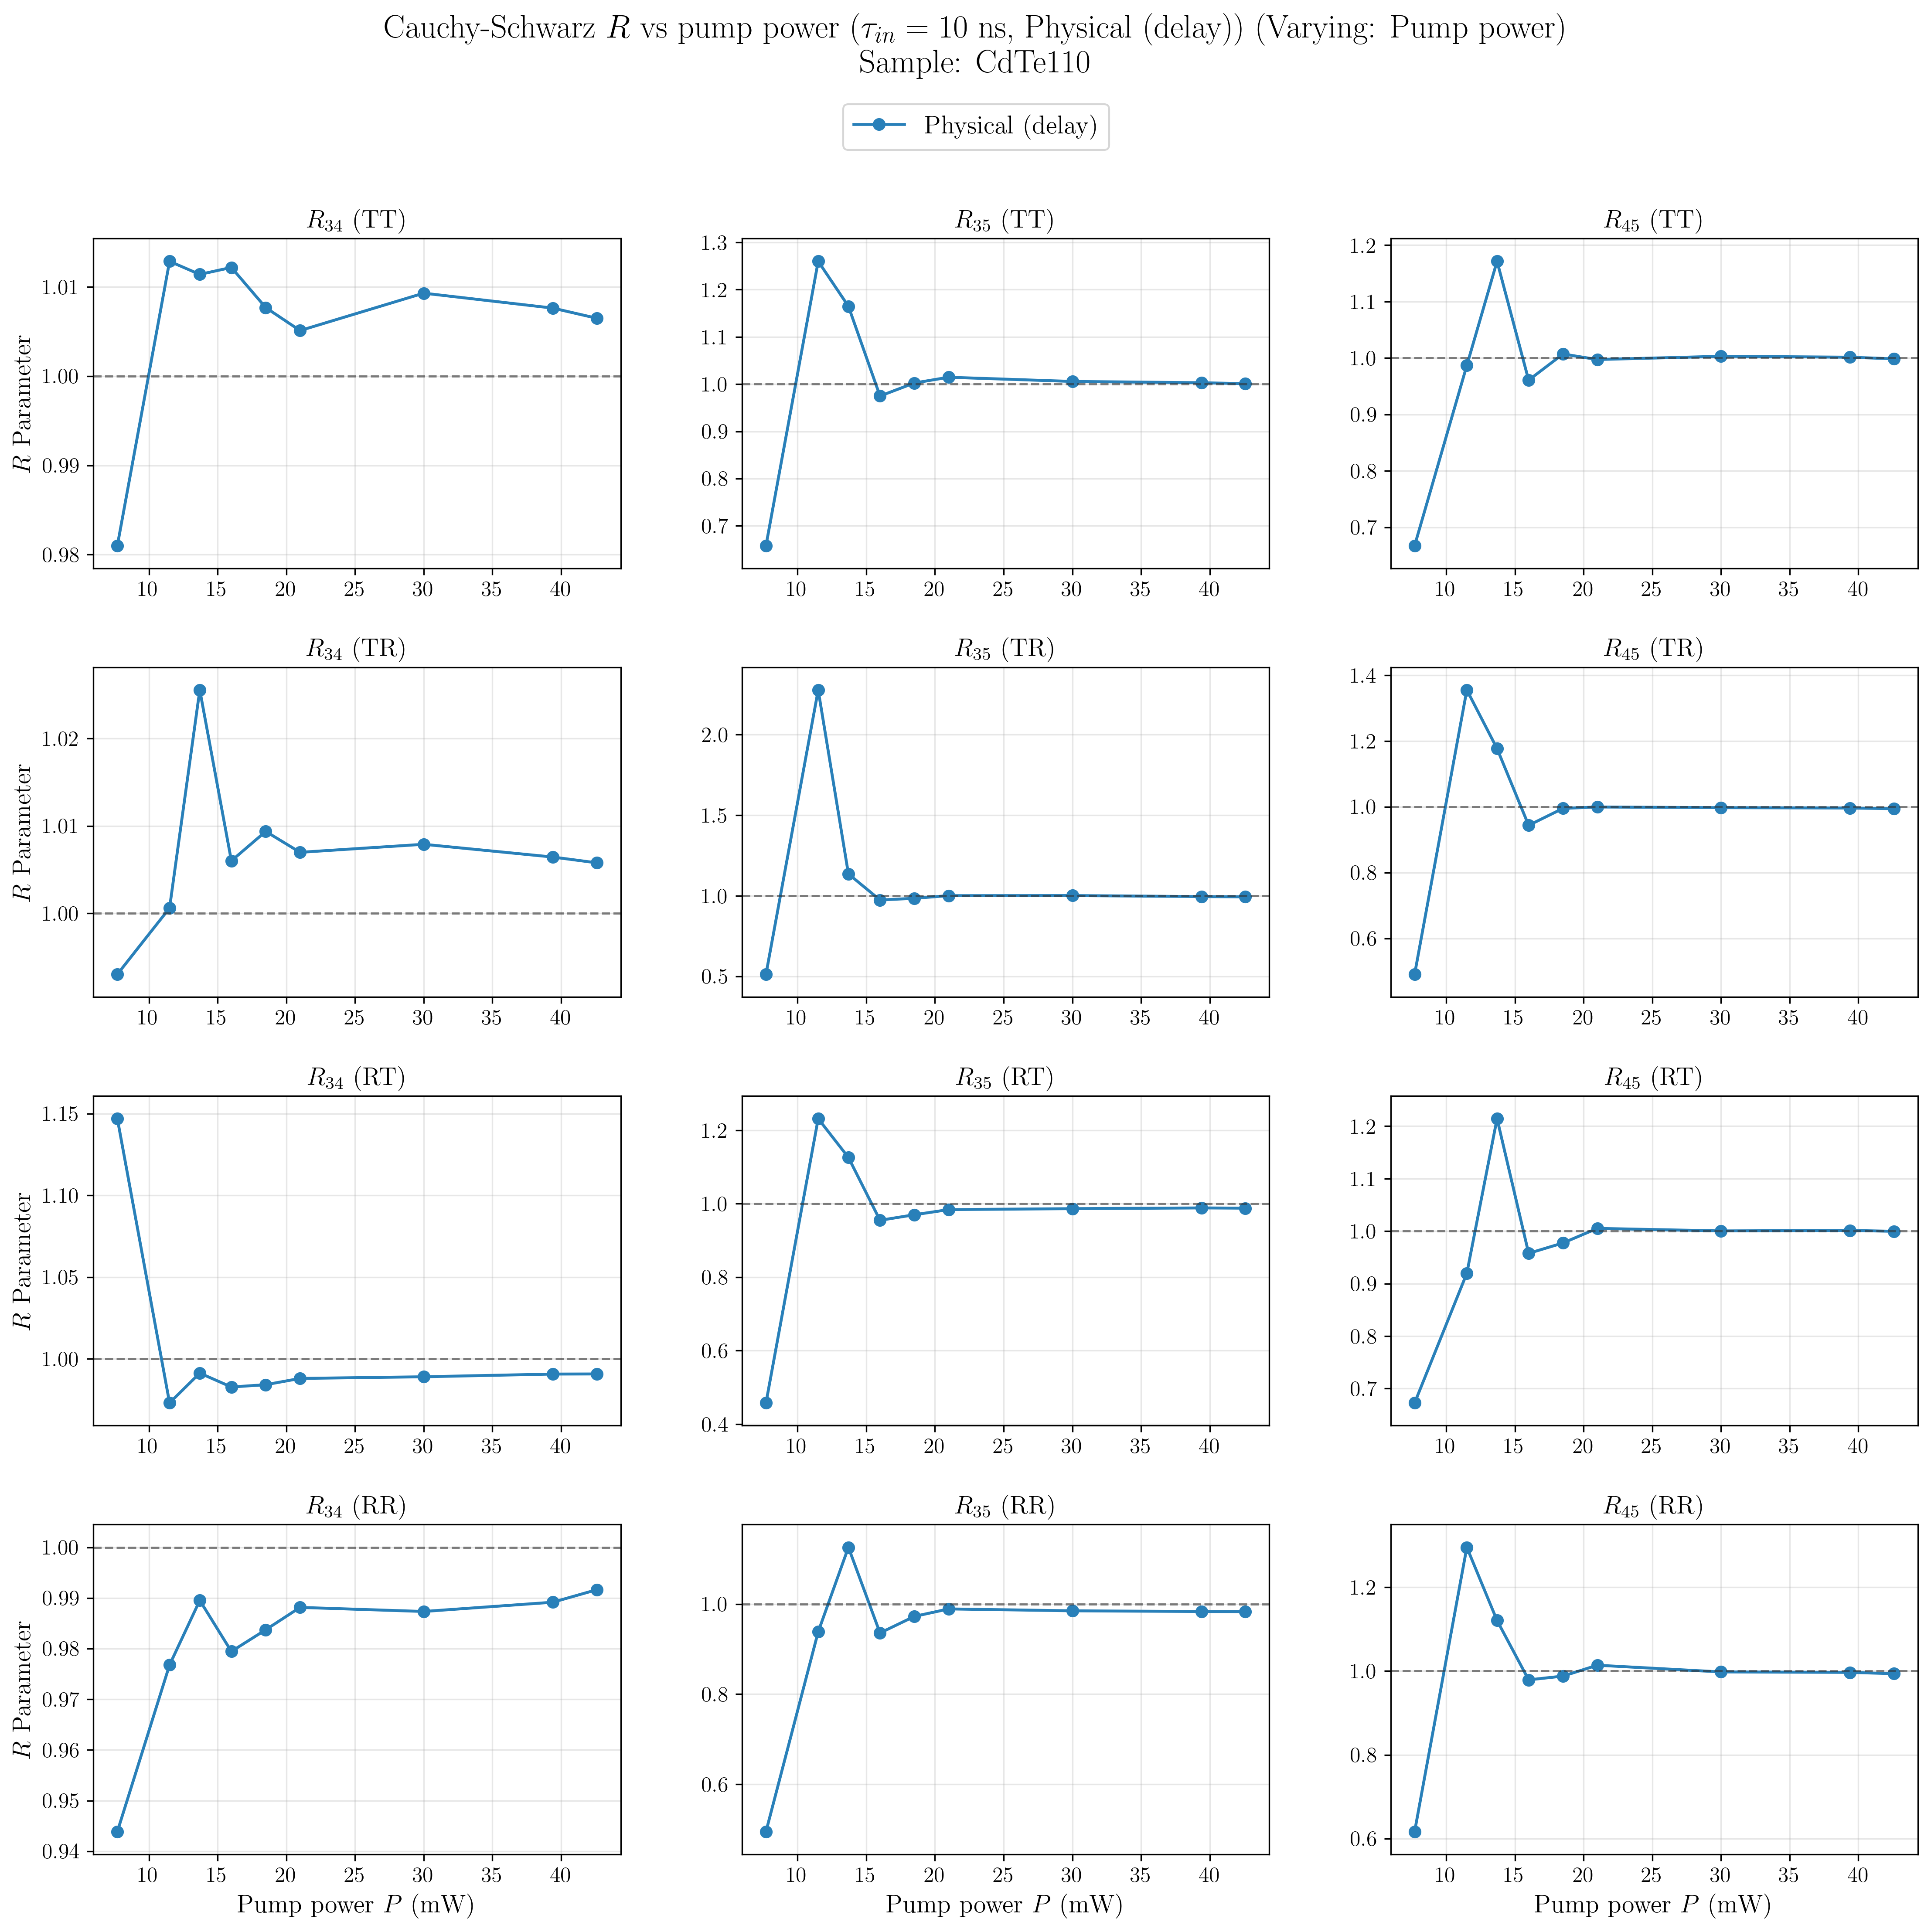

(<Figure size 5400x4800 with 12 Axes>,
 array([[<Axes: title={'center': '$R_{34}$ (TT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TT)'}>,
         <Axes: title={'center': '$R_{45}$ (TT)'}>],
        [<Axes: title={'center': '$R_{34}$ (TR)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (TR)'}>,
         <Axes: title={'center': '$R_{45}$ (TR)'}>],
        [<Axes: title={'center': '$R_{34}$ (RT)'}, ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RT)'}>,
         <Axes: title={'center': '$R_{45}$ (RT)'}>],
        [<Axes: title={'center': '$R_{34}$ (RR)'}, xlabel='Pump power $P$ (mW)', ylabel='$R$ Parameter'>,
         <Axes: title={'center': '$R_{35}$ (RR)'}, xlabel='Pump power $P$ (mW)'>,
         <Axes: title={'center': '$R_{45}$ (RR)'}, xlabel='Pump power $P$ (mW)'>]],
       dtype=object))

In [10]:
comp.plot_power_scan_g2(tau_in_ns=TAU_INT, method='delay')
comp.plot_power_scan_R(tau_in_ns=TAU_INT, method='delay')